# Slingshot Solver v3.0
## Gravitational Slingshot Dynamics in Restricted 3-Body Systems

Production-grade implementation with layered architecture:
- **Core Layer** (`slingshot.core`): 3-body ODE dynamics, 2-body scattering math, IC sampling
- **Analysis Layer** (`slingshot.analysis`): Trajectory metrics, Monte Carlo workflows, encounter geometry
- **Output Layer** (`slingshot.output`): Plotting, animation, reporting, comparison utilities
- Configuration-driven pipeline (YAML / Pydantic v2)
- Canonical km-kg-s unit system with SI conversions
- Comprehensive diagnostics: 14+ diagnostic plots, planet-frame analysis, energy extraction
- Parallelized particle evaluation with star-proximity filtering
- Video rendering and multi-candidate overlays
- Cross-run comparison & narrowed 2-body baselines
- **v2.3**: Star proximity filter, planet-frame diagnostics
- **v2.4**: Unified pipeline, auto-generated REPORT.md
- **v3.0**: Layered restructure, packaging, CLI, full test suite

**System**: Kepler-432 (K0V star, 1.19 M☉; hot Jupiter, 5.2 M♃, a ≈ 0.0896 AU)

## Setup and Configuration

In [1]:
%matplotlib inline
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

# Add package to path
sys.path.insert(0, str(Path('.').resolve()))

import slingshot
from slingshot.constants import M_SUN, M_JUP, R_JUP, R_SUN
from slingshot.analysis.monte_carlo import (
    run_monte_carlo, select_top_indices,
    select_pareto_indices, select_weighted_indices,
)
from slingshot.output.plotting import (
    plot_mc_summary_individual,
    plot_best_candidate_with_bodies,
    plot_velocity_phase_space_individual,
    plot_star_proximity_distribution_individual,
    plot_multi_candidate_overlay, plot_rejection_breakdown,
    plot_parameter_correlations_individual,
    plot_energy_cdf,
    plot_sampling_parameter_distributions,
    plot_publication_objectives_individual,
    plot_candidate_ranking_diagnostics_individual,
    plot_pareto_front_2d, plot_scalar_vs_vector_tradeoff,
    plot_convergence_curves, plot_uncertainty_bands, plot_sensitivity_tornado,
)
from slingshot.output.animation import generate_all_animations
from slingshot.analysis.baselines import compare_3body_with_baselines
from slingshot.output.report import generate_run_report
from slingshot.analysis.uncertainty import (
    run_parameter_posterior_mc, compute_confidence_bands, bootstrap_pareto_stability,
)
from slingshot.analysis.robustness import (
    run_convergence_test, run_numerical_sensitivity, format_robustness_table,
)

# ── Plot constants ──────────────────────────────────────────────────
LANDSCAPE_SIZE = (14, 8)
PLOT_DPI = 150

# ── Helper: save a single figure and display it ────────────────────
def save_and_show(fig, path, saved_plots):
    """Save *fig* to *path*, append to saved_plots list, display & close."""
    if fig is None:
        return
    fig.savefig(str(path), dpi=PLOT_DPI, bbox_inches="tight")
    saved_plots.append(str(path))
    display(fig)
    plt.close(fig)

# ── Helper: save a dict of {filename: fig} into output_dir ────────
def save_and_show_dict(figs, output_dir, saved_plots):
    """Save each fig in *figs* dict to output_dir/key, display & close."""
    if not figs:
        return
    for fname, fig in figs.items():
        p = Path(output_dir) / fname
        fig.savefig(str(p), dpi=PLOT_DPI, bbox_inches="tight")
        saved_plots.append(str(p))
        display(fig)
        plt.close(fig)

print(f"Slingshot Solver v{slingshot.__version__}")
print(f"Unit system: km-kg-s  (energy: km²/s² ≡ MJ/kg)")
print(f"NumPy: {np.__version__}")

Slingshot Solver v3.0.0
Unit system: km-kg-s  (energy: km²/s² ≡ MJ/kg)
NumPy: 2.1.3


### Load Configuration

Choose between:
1. **Load from file** (recommended): YAML or JSON config
2. **Create in-place**: Python dict or FullConfig object
3. **Predefined system**: Quick setup by system name

In [2]:
import importlib
import slingshot.config
importlib.reload(slingshot.config)
from slingshot.config import load_config, FullConfig

# Option 1: Load from YAML file
cfg = load_config('configs/config_k432.yaml')

# Option 2: Create configuration in Python
'''
from slingshot.config import (
    SystemConfig, SamplingConfig, NumericalConfig,
    PipelineConfig, FullConfig
)

cfg = FullConfig(
    system=SystemConfig(
        name="Kepler-432",
        M_star_Msun=1.19,
        R_star_Rsun=4.06,
        M_planet_Mjup=5.2,
        R_planet_Rjup=1.14,
        a_planet_AU=0.0896,
    ),
    sampling=SamplingConfig(
        mode="uniform",
        v_mag_min_kms=5.0,
        v_mag_max_kms=200.0,
        impact_param_min_AU=0.0001,
        impact_param_max_AU=0.005,
        angle_in_min_deg=-180.0,
        angle_in_max_deg=180.0,
        bary_unbound_requirement=True,
    ),
    numerical=NumericalConfig(
        rtol=1e-12,
        atol=1e-12,
        ode_method="DOP853",
        softening_km=100.0,
        r_far_factor=10.0,
        min_clearance_factor=2.0,
        flyby_r_min_max_hill=0.5,
        escape_radius_factor=5.0,
        star_min_clearance_Rstar=1.0,
    ),
    pipeline=PipelineConfig(
        N_particles=24000,
        n_parallel=8,
        t_mc_max_sec=5e8,
    ),
)
'''

print(f"Loaded configuration: {cfg.system.name}")
print(f"  Star:    {cfg.system.M_star_Msun:.2f} M☉ (R = {cfg.system.R_star_Rsun:.2f} R☉)")
print(f"  Planet:  {cfg.system.M_planet_Mjup:.1f} M♃ (R = {cfg.system.R_planet_Rjup:.2f} R♃)")
print(f"  Orbit:   {cfg.system.a_planet_AU:.4f} AU")
print(f"  MC Size: {cfg.pipeline.N_particles:,} particles")
print(f"  Star clearance filter: {cfg.numerical.star_min_clearance_Rstar} R★")

# Override plot constants from config
LANDSCAPE_SIZE = tuple(cfg.visualization.figure_size_landscape)
PLOT_DPI = cfg.visualization.figure_dpi
print(f"  Plot size: {LANDSCAPE_SIZE}, DPI: {PLOT_DPI}")

Loaded configuration: Kepler-432
  Star:    1.19 M☉ (R = 4.06 R☉)
  Planet:  5.2 M♃ (R = 1.16 R♃)
  Orbit:   0.0896 AU
  MC Size: 1,000 particles
  Star clearance filter: 3.0 R★
  Plot size: (10.0, 8.0), DPI: 100


## Phase 1: Monte Carlo Sweep

Sample and integrate N test particles through encounters.

In [3]:
# Derive physical quantities from config + canonical constants
m_star = cfg.system.M_star_Msun * M_SUN
m_p = cfg.system.M_planet_Mjup * M_JUP
R_p = cfg.system.R_planet_Rjup * R_JUP

print(f"Physical parameters (from slingshot.constants):")
print(f"  Star: {cfg.system.M_star_Msun:.2f} M☉  ({m_star:.3e} kg)")
print(f"  Planet: {cfg.system.M_planet_Mjup:.1f} M♃  (R={R_p:.0f} km)")
print(f"  Orbit: {cfg.system.a_planet_AU:.4f} AU")
print(f"  Phase: {cfg.system.orbital_phase_rad:.3f} rad  Prograde: {cfg.system.prograde}")
print()

# Run Monte Carlo
print("Running Monte Carlo sweep …")
print(f"  Particles: {cfg.pipeline.N_particles}")
print(f"  Timespan: {cfg.pipeline.t_mc_max_sec:.1e} s")
print(f"  ODE method: {cfg.numerical.ode_method}")
print(f"  Softening: {cfg.numerical.softening_km:.1f} km")
if cfg.numerical.star_min_clearance_Rstar is not None:
    print(f"  Star filter: {cfg.numerical.star_min_clearance_Rstar:.1f} R★")

mc = run_monte_carlo(
    N=cfg.pipeline.N_particles,
    t_span=(0.0, cfg.pipeline.t_mc_max_sec),
    m_star=m_star,
    m_p=m_p,
    R_p=R_p,
    frame="barycentric",
    sampling_mode=cfg.sampling.mode,
    n_parallel=cfg.pipeline.n_parallel,
    verbose=True,
    # Sampling bounds
    v_mag_min=cfg.sampling.v_mag_min_kms,
    v_mag_max=cfg.sampling.v_mag_max_kms,
    impact_param_min_AU=cfg.sampling.impact_param_min_AU,
    impact_param_max_AU=cfg.sampling.impact_param_max_AU,
    angle_in_min_deg=cfg.sampling.angle_in_min_deg,
    angle_in_max_deg=cfg.sampling.angle_in_max_deg,
    r_init_AU=cfg.sampling.r_init_AU,
    # Optional system bulk velocity (Galilean boost)
    bulk_velocity_vx_kms=cfg.system.bulk_velocity_vx_kms,
    bulk_velocity_vy_kms=cfg.system.bulk_velocity_vy_kms,
    # Orbital geometry
    orbital_phase_rad=cfg.system.orbital_phase_rad,
    prograde=cfg.system.prograde,
    # Numerical
    rtol=cfg.numerical.rtol,
    atol=cfg.numerical.atol,
    r_far_factor=cfg.numerical.r_far_factor,
    min_clearance_factor=cfg.numerical.min_clearance_factor,
    bary_unbound_requirement=cfg.sampling.bary_unbound_requirement,
    flyby_r_min_max_hill=cfg.numerical.flyby_r_min_max_hill,
    escape_radius_factor=cfg.numerical.escape_radius_factor,
    ode_method=cfg.numerical.ode_method,
    softening_km=cfg.numerical.softening_km,
    # Star proximity filter
    star_min_clearance_Rstar=cfg.numerical.star_min_clearance_Rstar,
    R_star_Rsun=cfg.system.R_star_Rsun,
)

ok_count = mc["ok"].sum()
print(f"\nResults: {ok_count}/{cfg.pipeline.N_particles} successful "
      f"({100.0*ok_count/cfg.pipeline.N_particles:.1f}%)")

# Show rejection breakdown
reasons = {}
for r in mc["results"]:
    if not r["ok"]:
        reasons[r["reason"]] = reasons.get(r["reason"], 0) + 1
if reasons:
    print(f"\nRejection breakdown:")
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        print(f"  {reason}: {count}")

Physical parameters (from slingshot.constants):
  Star: 1.19 M☉  (2.366e+30 kg)
  Planet: 5.2 M♃  (R=82573 km)
  Orbit: 0.0896 AU
  Phase: 0.000 rad  Prograde: True

Running Monte Carlo sweep …
  Particles: 1000
  Timespan: 5.0e+07 s
  ODE method: DOP853
  Softening: 1000.0 km
  Star filter: 3.0 R★
Monte Carlo: 1000 particles, barycentric frame, barycentric sampling
  System bulk velocity: (10.00, 0.00) km/s |v|=10.00 km/s
  Hill sphere: 1496020 km (0.0100 AU)
  Flyby r_min threshold: 7480102 km (5.0 × r_Hill)
  Star filter: r_min_star > 3.0 R★ (8477280 km)
  Completed: 100/1000
  Completed: 200/1000
  Completed: 300/1000
  Completed: 400/1000
  Completed: 500/1000
  Completed: 600/1000
  Completed: 700/1000
  Completed: 800/1000
  Completed: 900/1000
  Completed: 1000/1000
Results: 39/1000 successful (3.9%)

Results: 39/1000 successful (3.9%)

Rejection breakdown:
  flyby_too_distant: 878
  star_too_close: 80
  bary_unbound_requirement_failed: 2
  analysis_failed: 1


In [4]:
# Create output directory for this run (used by all plot cells below)
from datetime import datetime

output_dir = Path(f"./results/results_{cfg.system.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

# Track all saved plot paths for the report
saved_plots = []

# Derive physical constants used throughout
R_star_km = cfg.system.R_star_Rsun * R_SUN

Output directory: results\results_Kepler-432_20260308_211601


### MC Summary Visualization

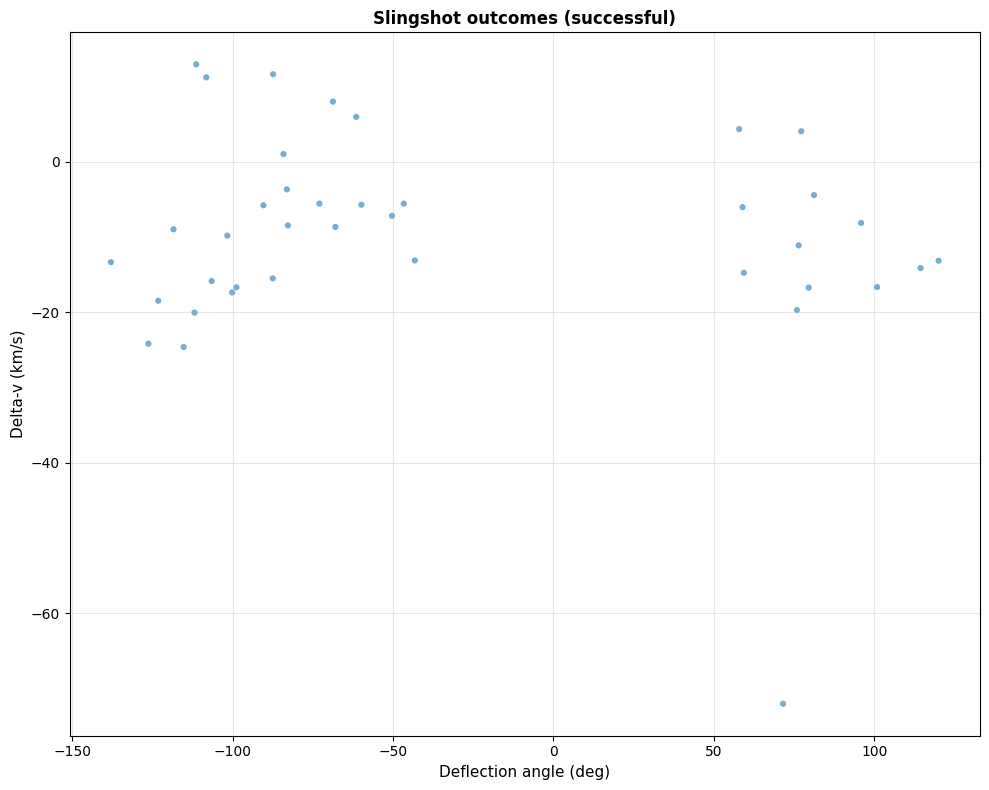

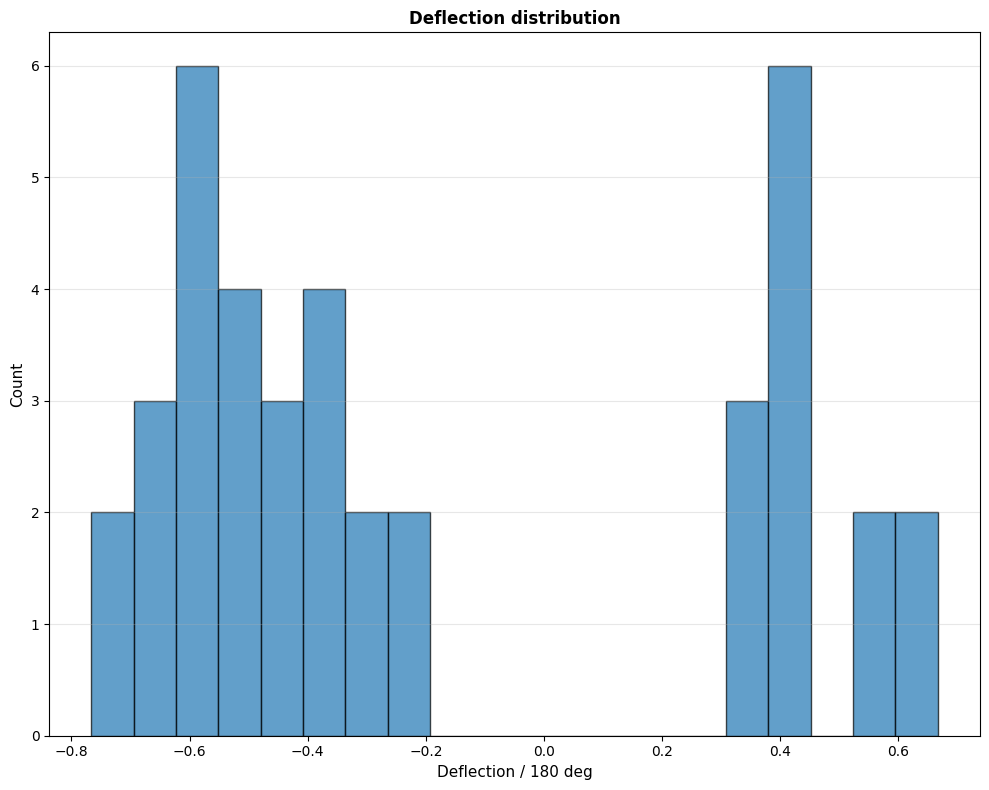


Monte Carlo Summary Statistics:
  Δv range: [-72.04, 12.95] km/s
  Δv mean: -9.91 ± 13.94 km/s
  Deflection range: [-137.9, 120.0]°
  Deflection mean: -32.7 ± 84.6°


In [5]:
# MC summary — individual panels (matching pipeline)
figs = plot_mc_summary_individual(mc, figsize=LANDSCAPE_SIZE)

if figs:
    if "save_and_show_dict" in globals():
        save_and_show_dict(figs, output_dir, saved_plots)
    else:
        # Fallback if helper cell was not executed
        dpi = PLOT_DPI if "PLOT_DPI" in globals() else 150
        for fname, fig in figs.items():
            p = output_dir / fname
            fig.savefig(str(p), dpi=dpi, bbox_inches="tight")
            saved_plots.append(str(p))
            display(fig)
            plt.close(fig)
else:
    print("  ! MC summary plots unavailable")

# Print statistics
delta_v_success = mc["delta_v"][mc["ok"]]
deflection_success = mc["deflection"][mc["ok"]]

print(f"\nMonte Carlo Summary Statistics:")
print(f"  Δv range: [{delta_v_success.min():.2f}, {delta_v_success.max():.2f}] km/s")
print(f"  Δv mean: {delta_v_success.mean():.2f} ± {delta_v_success.std():.2f} km/s")
print(f"  Deflection range: [{deflection_success.min():.1f}, {deflection_success.max():.1f}]°")
print(f"  Deflection mean: {deflection_success.mean():.1f} ± {deflection_success.std():.1f}°")

### Sampling Parameter Distributions

Proposal-space coverage and config cutoff overlays for each sampling parameter.

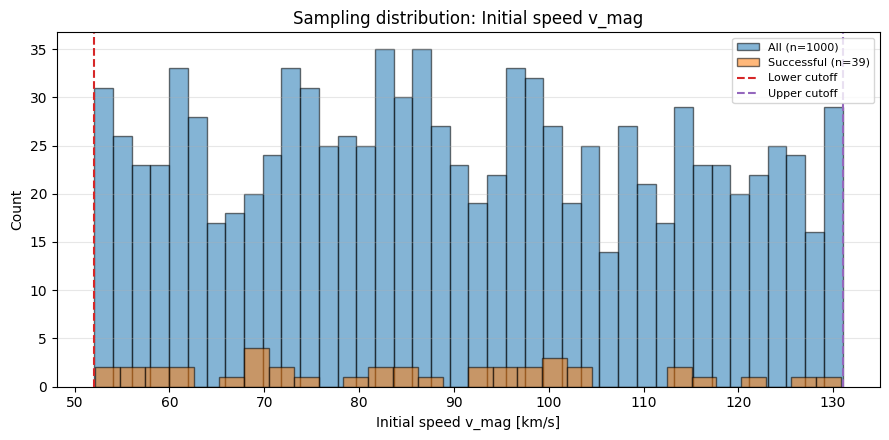

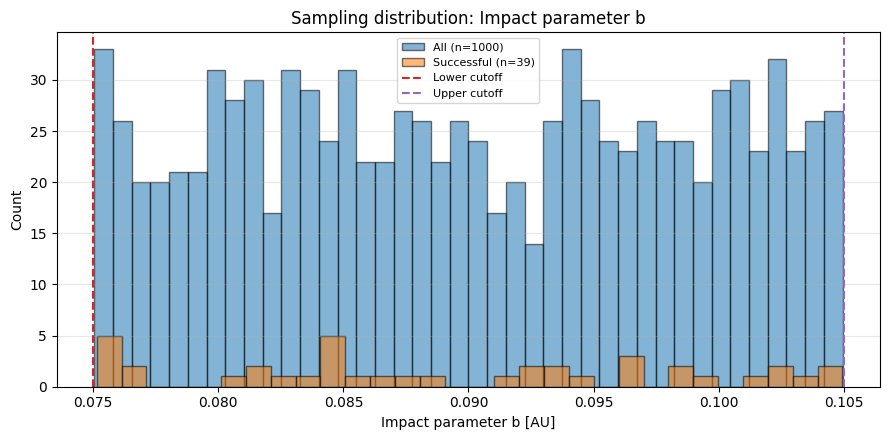

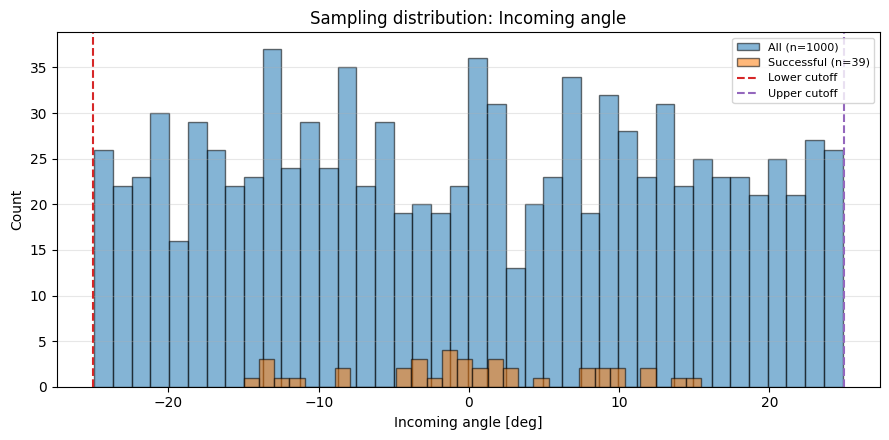

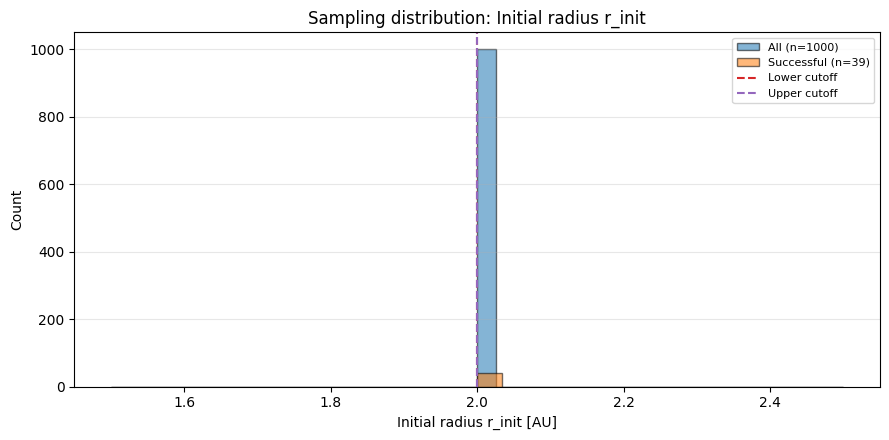

In [6]:
# Sampling-parameter distributions (config proposal-space coverage + cutoffs)
param_figs = plot_sampling_parameter_distributions(mc, cfg=cfg, save_dir=None, dpi=PLOT_DPI)
if param_figs:
    save_and_show_dict(param_figs, output_dir, saved_plots)
else:
    print("  ! sampling parameter distributions unavailable")

### MC Diagnostic Plots

Rejection breakdown, parameter correlations (individual panels), star proximity
distribution (individual panels).

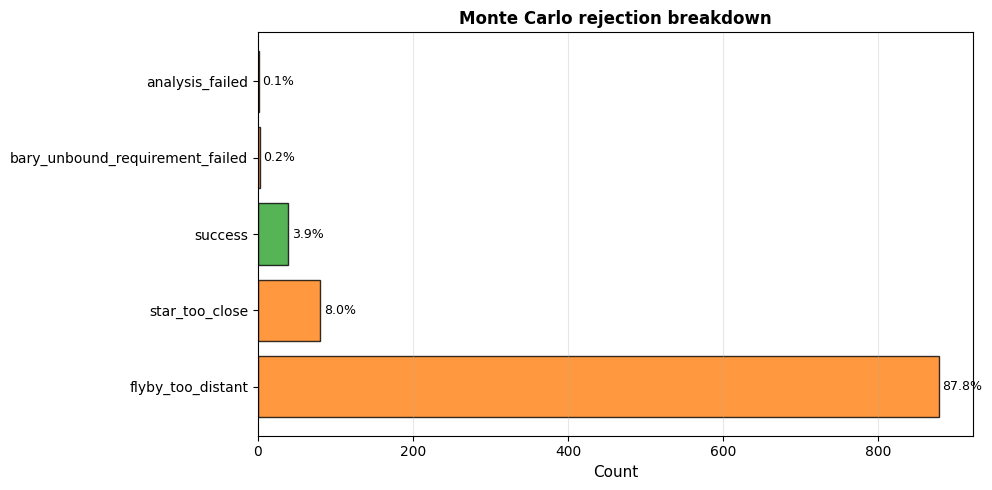

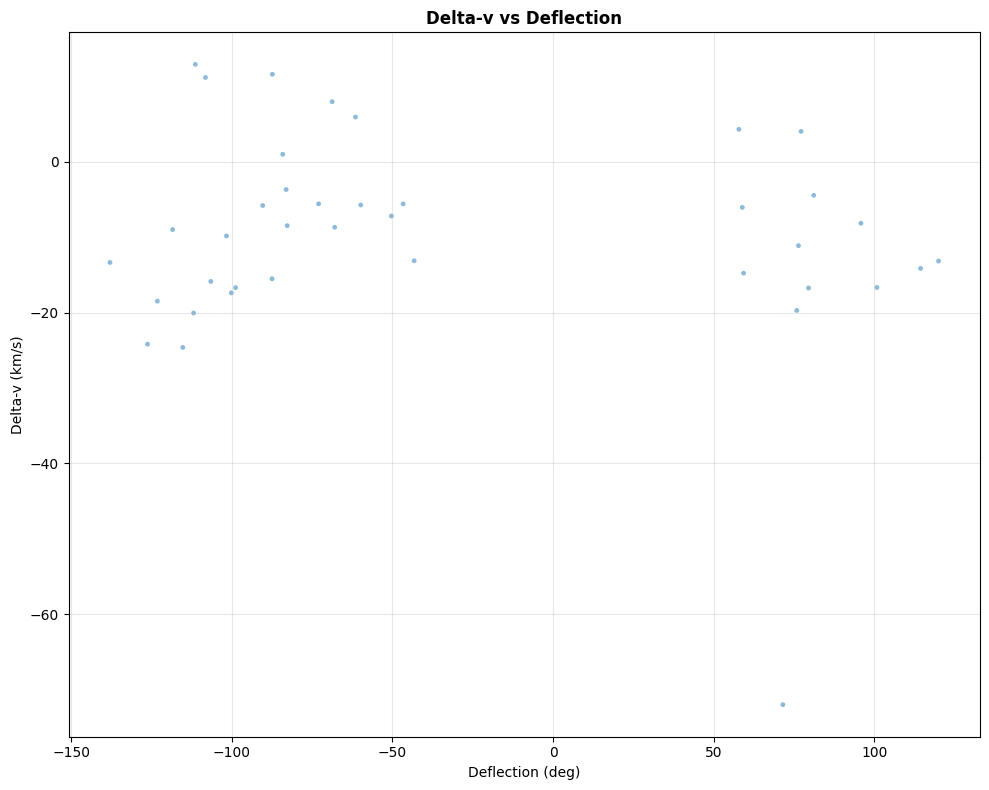

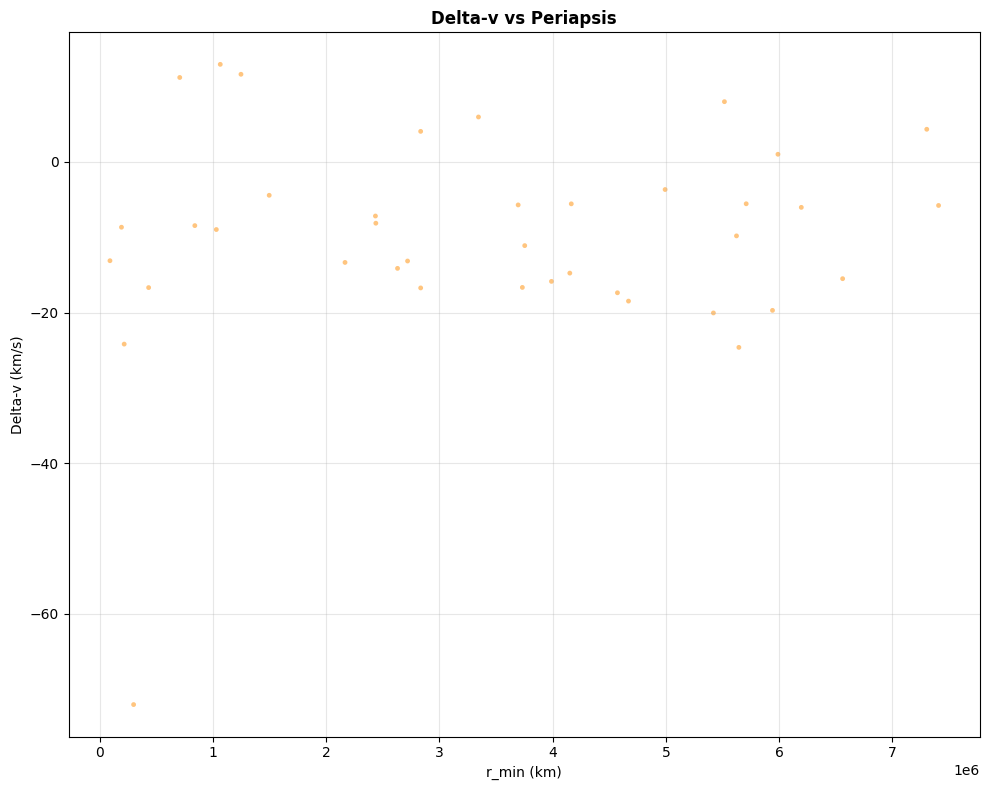

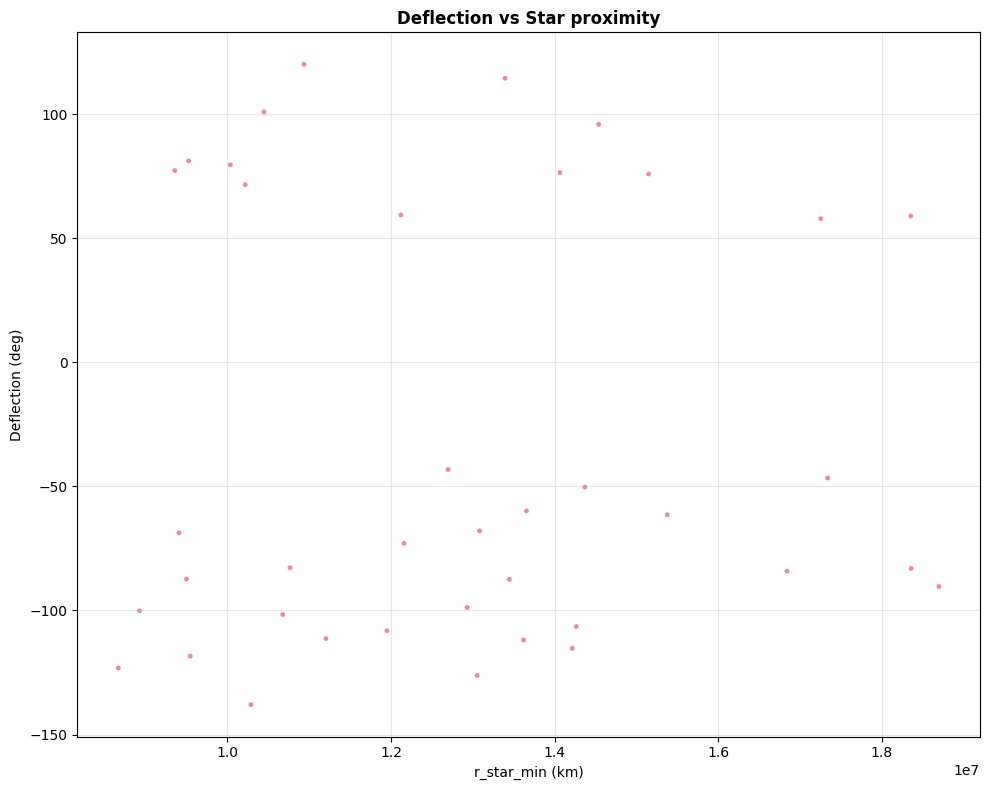

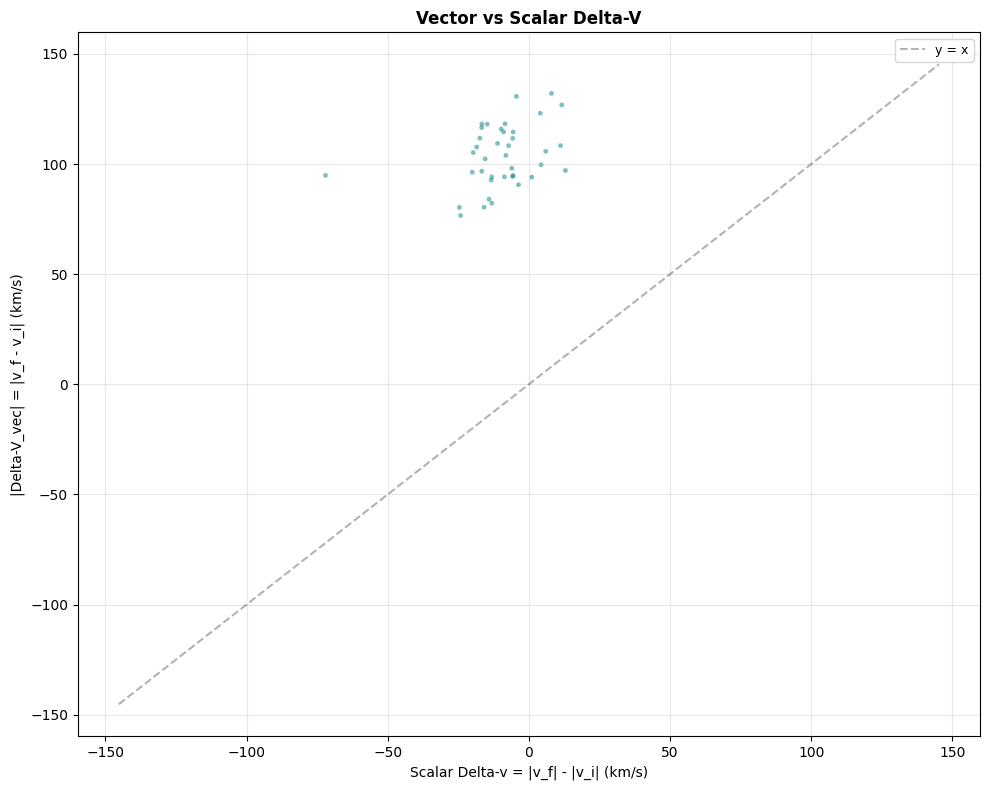

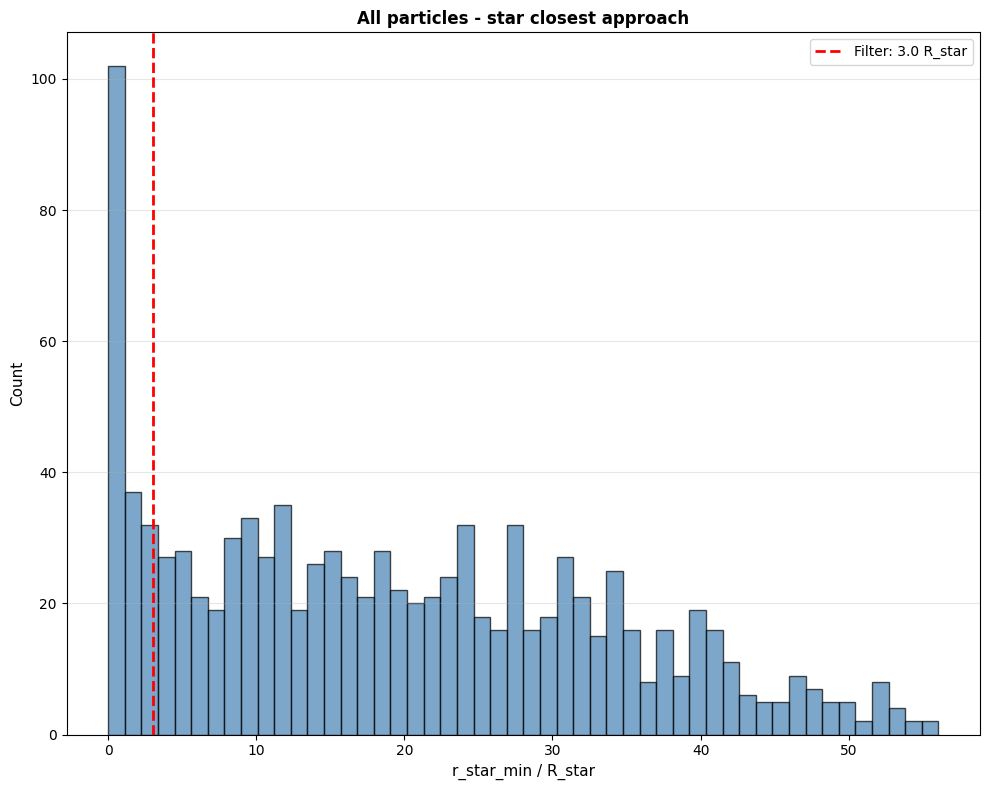

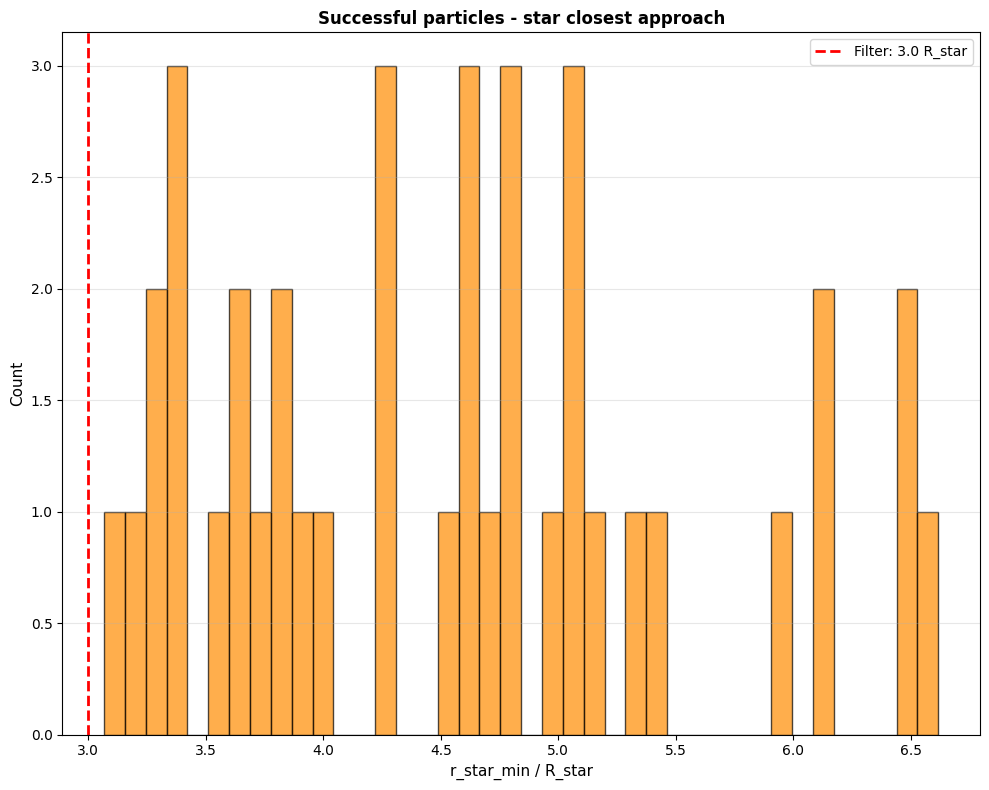

In [7]:
# Rejection breakdown
save_and_show(
    plot_rejection_breakdown(mc, save_dir=None, dpi=PLOT_DPI),
    output_dir / "rejection_breakdown.png", saved_plots,
)

# Parameter correlations — individual panels
save_and_show_dict(
    plot_parameter_correlations_individual(mc, figsize=LANDSCAPE_SIZE),
    output_dir, saved_plots,
)

# Star proximity distribution — individual panels
star_clearance = cfg.numerical.star_min_clearance_Rstar
save_and_show_dict(
    plot_star_proximity_distribution_individual(
        mc, R_star_km, clearance_Rstar=star_clearance, figsize=LANDSCAPE_SIZE,
    ),
    output_dir, saved_plots,
)

## Phase 2: Top Candidate Selection

Supports single-metric, Pareto, or weighted multi-objective selection modes.

In [8]:
mode = cfg.pipeline.select_mode

if mode == "single":
    top_idx = select_top_indices(
        mc,
        top_frac=cfg.pipeline.top_frac,
        min_top=cfg.pipeline.min_top,
        metric=cfg.pipeline.select_metric,
        sign=cfg.pipeline.select_sign,
    )
    print(f"Selection mode: single  "
          f"(metric={cfg.pipeline.select_metric}, sign={cfg.pipeline.select_sign})")
else:
    objectives = [
        {"metric": o.metric, "sign": o.sign, "weight": o.weight}
        for o in cfg.pipeline.selection_objectives
    ]
    if mode == "pareto":
        top_idx = select_pareto_indices(
            mc, objectives=objectives,
            top_frac=cfg.pipeline.top_frac,
            min_top=cfg.pipeline.min_top,
            tie_break_normalization=cfg.pipeline.weighted_normalization,
        )
    elif mode == "weighted":
        top_idx = select_weighted_indices(
            mc, objectives=objectives,
            top_frac=cfg.pipeline.top_frac,
            min_top=cfg.pipeline.min_top,
            normalization=cfg.pipeline.weighted_normalization,
        )
    else:
        raise ValueError(f"Unknown select_mode: {mode}")

    obj_txt = ", ".join(f"{o['metric']}:{o['sign']}@{o['weight']:.2g}" for o in objectives)
    print(f"Selection mode: {mode}  "
          f"(norm={cfg.pipeline.weighted_normalization}; objectives={obj_txt})")

print(f"Selected {len(top_idx)} top candidates (top {cfg.pipeline.top_frac*100:.0f}%)")
print(f"Indices: {top_idx}")

# Show top candidates
print("\nTop 5 candidates:")
for rank, idx in enumerate(top_idx[:5], 1):
    dv = mc["delta_v"][idx]
    defl = mc["deflection"][idx]
    print(f"  {rank}. MC#{idx}: Δv={dv:.2f} km/s, deflection={defl:.1f}°")

Selection mode: pareto  (norm=minmax; objectives=bary_delta_v:maximize@1, delta_v_vec:maximize@1, energy_from_planet_orbit:maximize@1)
Selected 5 top candidates (top 10%)
Indices: [ 48 430 616 133 184]

Top 5 candidates:
  1. MC#48: Δv=12.95 km/s, deflection=-111.3°
  2. MC#430: Δv=7.99 km/s, deflection=-68.7°
  3. MC#616: Δv=11.63 km/s, deflection=-87.4°
  4. MC#133: Δv=4.05 km/s, deflection=77.2°
  5. MC#184: Δv=11.21 km/s, deflection=-108.2°


## Phase 3: High-Resolution Re-run

Re-integrate top candidates at higher resolution.

In [9]:
import importlib
import slingshot.core.dynamics
importlib.reload(slingshot.core.dynamics)

from slingshot.core.dynamics import simulate_3body
from slingshot.analysis.trajectory import analyze_trajectory
from slingshot.constants import R_SUN

print(f"Re-running {len(top_idx)} candidates at high resolution...")
print(f"  Timespan: {cfg.pipeline.t_best_max_sec:.1e} s")
print(f"  Output points: {cfg.pipeline.n_eval_best}")
print(f"  Escape radius factor: {cfg.numerical.escape_radius_factor:.1f}×")
print(f"  ODE method: {cfg.numerical.ode_method}")
print(f"  Softening: {cfg.numerical.softening_km:.1f} km")

# Star filter for high-res candidates
R_star_km = cfg.system.R_star_Rsun * R_SUN
star_clearance_Rstar = cfg.numerical.star_min_clearance_Rstar
if star_clearance_Rstar is not None:
    star_clearance_km = star_clearance_Rstar * R_star_km
    print(f"  Star filter: r_min_star > {star_clearance_Rstar:.1f} R★ ({star_clearance_km:.0f} km)")
else:
    star_clearance_km = None

Y_sp0 = mc["Y_sp0"]
sat_states = mc["sat_states"]

sols_best = []
analyses_best = []
Y0_best = []
star_rejected = 0

for i, idx in enumerate(top_idx):
    if i % max(1, len(top_idx)//10) == 0:
        print(f"  Progress: {i+1}/{len(top_idx)}")
    
    # Reconstruct initial state
    xs, ys, vxs, vys, xp, yp, vxp, vyp = Y_sp0
    x3, y3, vx3, vy3 = sat_states[idx]
    Y0 = np.array([xs, ys, vxs, vys, xp, yp, vxp, vyp, x3, y3, vx3, vy3], dtype=float)
    
    # Escape radius: particle's initial barycentric distance × escape_radius_factor
    r0_bary = np.sqrt(x3**2 + y3**2)
    escape_r = r0_bary * cfg.numerical.escape_radius_factor
    
    # Integrate at high resolution (with terminal event for escape)
    sol = simulate_3body(
        Y0,
        (0.0, cfg.pipeline.t_best_max_sec),
        m_star=m_star,
        m_p=m_p,
        n_eval=cfg.pipeline.n_eval_best,
        rtol=cfg.numerical.rtol,
        atol=cfg.numerical.atol,
        escape_radius_km=escape_r,
        method=cfg.numerical.ode_method,
        softening_km=cfg.numerical.softening_km,
    )
    
    # Analyze
    ana = analyze_trajectory(
        sol,
        frame="barycentric",
        m_star=m_star,
        m_p=m_p,
        R_p=R_p,
        r_far_factor=cfg.numerical.r_far_factor,
        min_clearance_factor=cfg.numerical.min_clearance_factor,
    )
    
    # Post-hoc star filter on high-res candidates
    if ana is not None and star_clearance_km is not None:
        enc_hr = ana.get("encounter")
        if enc_hr is not None and enc_hr.r_star_min is not None:
            if enc_hr.r_star_min < star_clearance_km:
                ana = None  # Mark as invalid
                star_rejected += 1
    
    sols_best.append(sol)
    analyses_best.append(ana)
    Y0_best.append(Y0)

valid_count = sum(1 for a in analyses_best if a is not None)
print(f"Re-run complete: {valid_count}/{len(top_idx)} valid")
if star_rejected > 0:
    print(f"  Star-proximity rejected: {star_rejected}")

Re-running 5 candidates at high resolution...
  Timespan: 5.0e+07 s
  Output points: 0
  Escape radius factor: 3.0×
  ODE method: DOP853
  Softening: 1000.0 km
  Star filter: r_min_star > 3.0 R★ (8477280 km)
  Progress: 1/5
  Progress: 2/5
  Progress: 3/5
  Progress: 4/5
  Progress: 5/5
Re-run complete: 5/5 valid


## Phase 4: Detailed Analysis & Visualization

### Best Candidate Trajectory

In [10]:
from slingshot.constants import R_SUN
R_star = cfg.system.R_star_Rsun * R_SUN

def _print_candidate(label, ana, orig_idx):
    enc = ana["encounter"]
    r_star_min_val = enc.r_star_min if enc and enc.r_star_min is not None else float('nan')
    print(f"{'='*60}")
    print(f"  {label}  (MC index #{orig_idx})")
    print(f"{'='*60}")
    print(f"  Δv (scalar):     {ana['delta_v']:>10.2f} km/s  ({ana['delta_v_pct']:+.1f}%)")
    print(f"  |ΔV_vec|:        {ana.get('delta_v_vec', float('nan')):>10.2f} km/s")
    print(f"  ½|ΔV_vec|²:      {ana.get('energy_half_dv_vec_sq', float('nan')):>10.2f} km²/s²")
    print(f"  Deflection:      {ana['deflection']:>10.1f}°  ({ana['deflection_frac']:.3f}×180)")
    print(f"  r_min (planet):  {ana['r_min']:>10.0f} km  ({ana['r_min']/R_p:.1f} R_p)")
    print(f"  r_min (star):    {r_star_min_val:>10.0f} km  ({r_star_min_val/R_star:.1f} R★)")
    print(f"  Impact param:    {ana['impact_parameter']:>10.0f} km")
    print(f"  Unbound (final): {str(ana['unbound_f']):>10s}")
    print(f"  ε_i:             {ana['eps_i']:>10.3e} km²/s²")
    print(f"  ε_f:             {ana['eps_f']:>10.3e} km²/s²")
    # Planet-frame diagnostics (energy extraction analysis)
    dvpf = ana.get('delta_v_planet_frame', None)
    if dvpf is not None:
        print(f"  --- Planet-frame diagnostics ---")
        print(f"  v_rel planet (in):  {ana.get('v_rel_planet_in', float('nan')):>8.2f} km/s")
        print(f"  v_rel planet (out): {ana.get('v_rel_planet_out', float('nan')):>8.2f} km/s")
        print(f"  Δv planet frame:    {dvpf:>8.2f} km/s  (0 = pure 2-body; ≠0 = star effect)")
        print(f"  Planet deflection:  {ana.get('planet_deflection_deg', float('nan')):>8.1f}°")
        efpo = ana.get('energy_from_planet_orbit', float('nan'))
        print(f"  ε from planet orbit: {efpo:>8.3e} km²/s²  (energy extracted from binary KE)")
        print(f"  Δε monopole:        {ana.get('delta_eps_monopole', float('nan')):>8.3e} km²/s²")

# --- Best by scalar Δv (speed change) — primary metric ---
valid_best = [(i, analyses_best[i]) for i in range(len(analyses_best)) if analyses_best[i] is not None]
if not valid_best:
    print("ERROR: No valid candidates after star filter!")
else:
    best_local_idx = max(valid_best, key=lambda x: x[1]["delta_v"])[0]
    best_sol = sols_best[best_local_idx]
    best_ana = analyses_best[best_local_idx]
    best_original_idx = top_idx[best_local_idx]
    
    _print_candidate("BEST by scalar Δv (|v_f| − |v_i|)", best_ana, best_original_idx)
    
    # --- Best by vector |ΔV_vec| (scattering energy) ---
    best_vec_local_idx = max(valid_best, key=lambda x: x[1].get("delta_v_vec", 0))[0]
    best_vec_sol = sols_best[best_vec_local_idx]
    best_vec_ana = analyses_best[best_vec_local_idx]
    best_vec_original_idx = top_idx[best_vec_local_idx]
    
    if best_vec_local_idx != best_local_idx:
        print()
        _print_candidate("BEST by |ΔV_vec| (scattering)", best_vec_ana, best_vec_original_idx)
    else:
        print(f"\n  (Same candidate is best by both metrics)")
    print("="*60)

  BEST by scalar Δv (|v_f| − |v_i|)  (MC index #48)
  Δv (scalar):          12.95 km/s  (+24.8%)
  |ΔV_vec|:             97.05 km/s
  ½|ΔV_vec|²:         4708.91 km²/s²
  Deflection:          -111.3°  (-0.618×180)
  r_min (planet):     1065388 km  (12.9 R_p)
  r_min (star):      11204565 km  (4.0 R★)
  Impact param:       6935696 km
  Unbound (final):       True
  ε_i:              8.287e+02 km²/s²
  ε_f:              1.913e+03 km²/s²
  --- Planet-frame diagnostics ---
  v_rel planet (in):     98.04 km/s
  v_rel planet (out):    95.94 km/s
  Δv planet frame:       -2.10 km/s  (0 = pure 2-body; ≠0 = star effect)
  Planet deflection:      81.6°
  ε from planet orbit: 9.620e+02 km²/s²  (energy extracted from binary KE)
  Δε monopole:        1.225e+02 km²/s²

  BEST by |ΔV_vec| (scattering)  (MC index #430)
  Δv (scalar):           7.99 km/s  (+7.1%)
  |ΔV_vec|:            132.06 km/s
  ½|ΔV_vec|²:         8719.37 km²/s²
  Deflection:           -68.7°  (-0.382×180)
  r_min (planet):     55

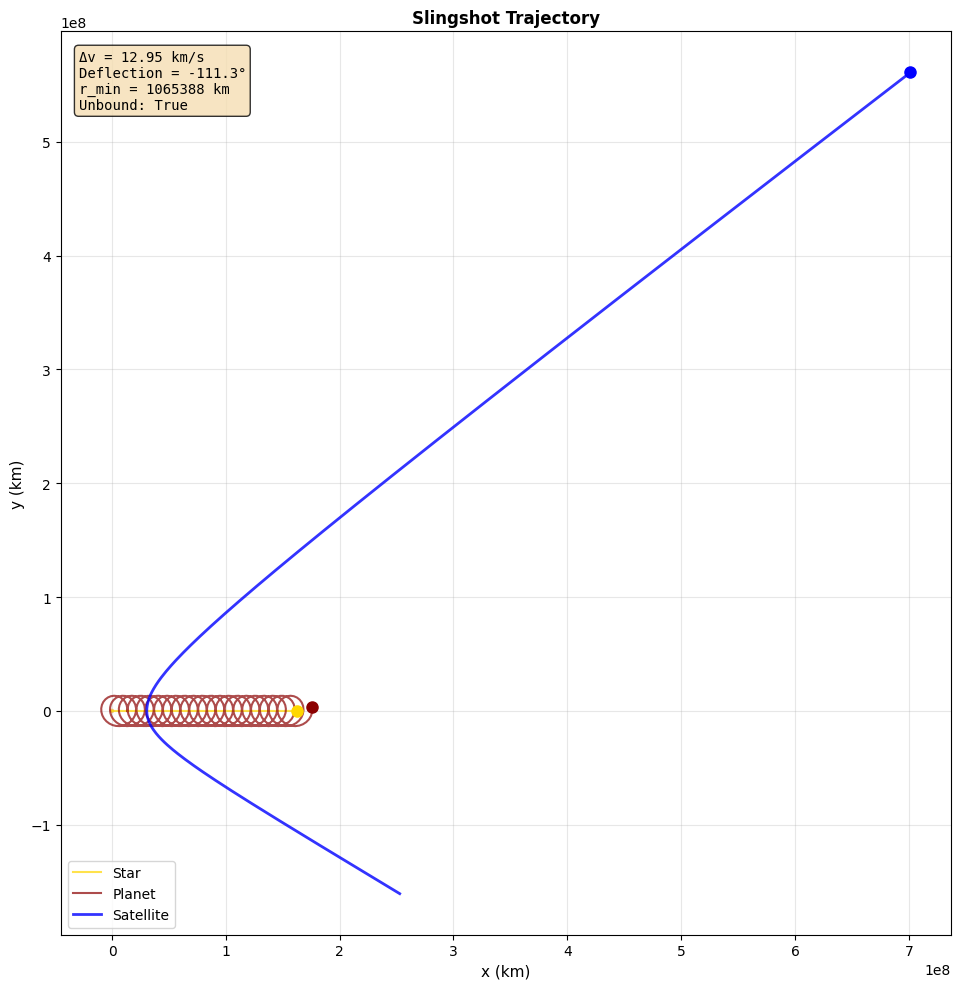

In [11]:
save_and_show(
    plot_best_candidate_with_bodies(best_sol, best_ana, m_star=m_star, m_p=m_p, R_p=R_p),
    output_dir / "best_candidate.png", saved_plots,
)

### Phase-Space Analysis

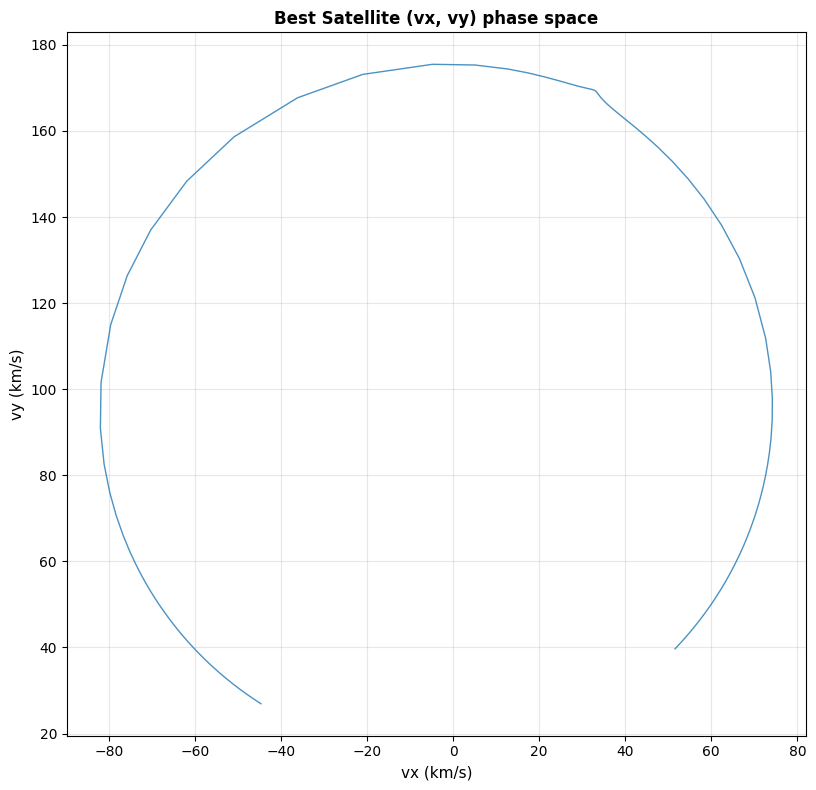

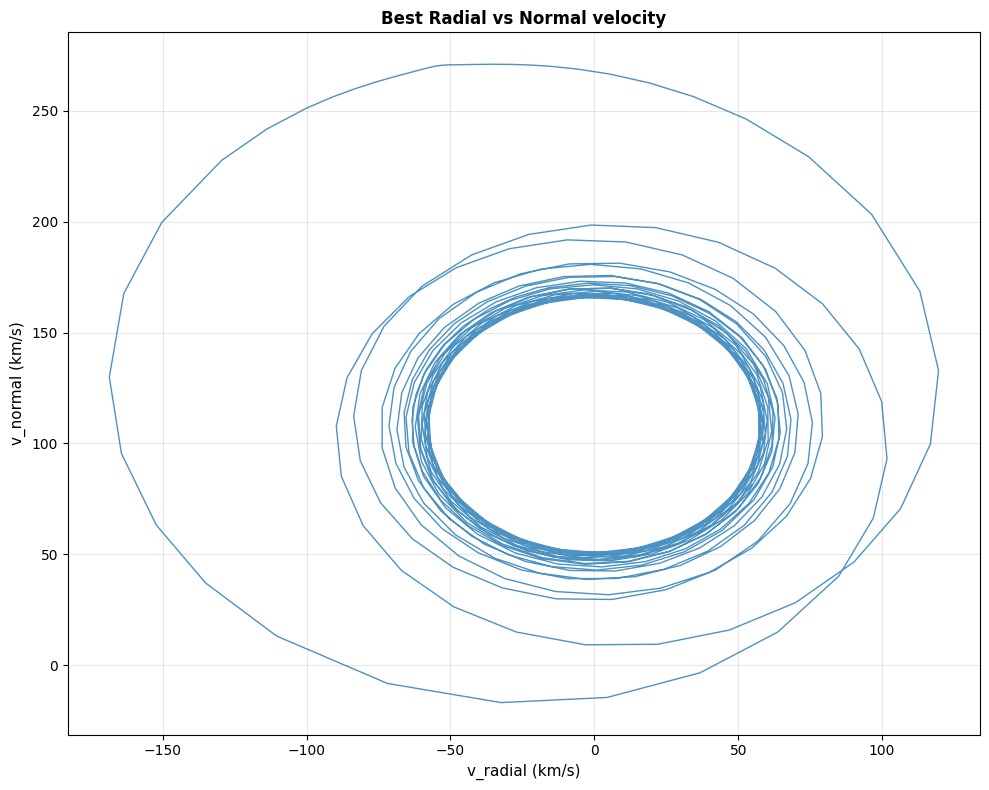

In [12]:
# Velocity phase space — individual panels
save_and_show_dict(
    plot_velocity_phase_space_individual(best_sol, title_prefix="Best", figsize=LANDSCAPE_SIZE),
    output_dir, saved_plots,
)

### Planet-Frame Diagnostics (Individual Panels)

Per-candidate energy extraction, deflection, speed change, and star proximity.

In [13]:
# Planet-frame diagnostics — disabled (star phase diagrams not up to standard)
# To re-enable, uncomment the block below:
# valid_ana = [a for a in analyses_best if a is not None]
# if valid_ana:
#     save_and_show_dict(
#         plot_planet_frame_diagnostics_individual(valid_ana, R_p, R_star_km, figsize=LANDSCAPE_SIZE),
#         output_dir, saved_plots,
#     )
print("  Star phase diagnostics: SKIPPED")

  Star phase diagnostics: SKIPPED


### Multi-Candidate Overlay

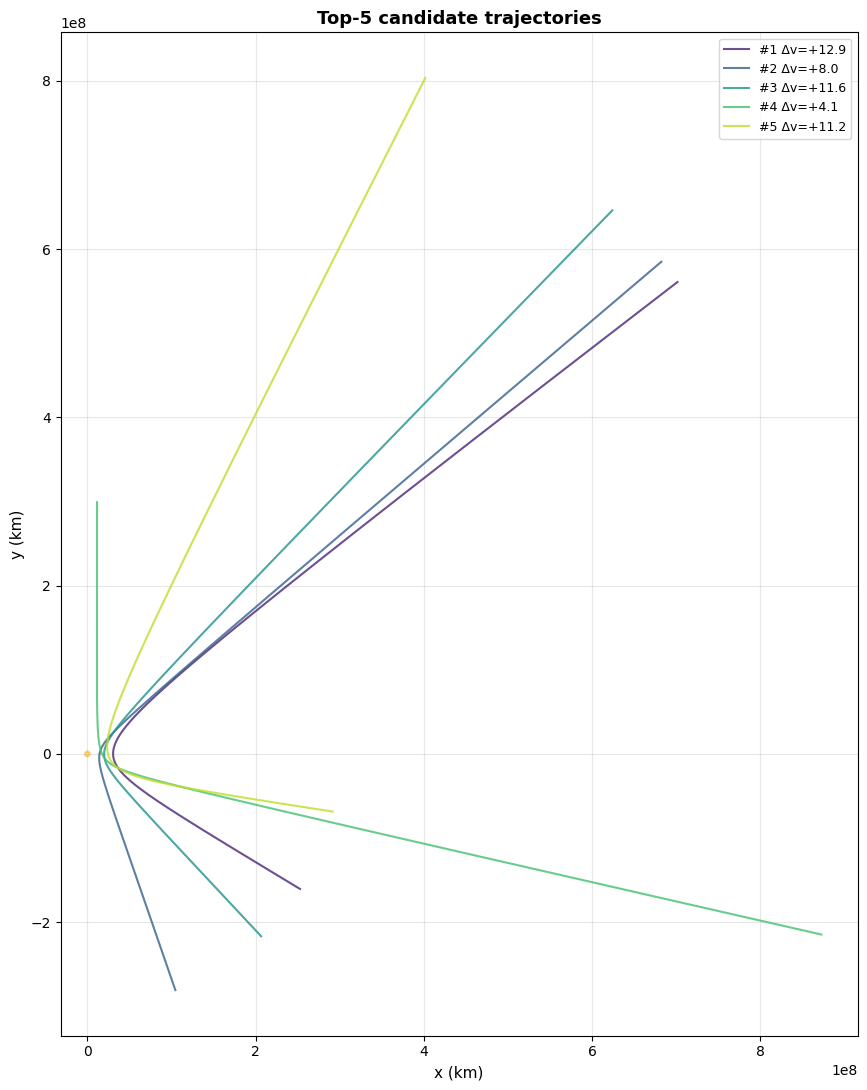

In [14]:
# Multi-candidate overlay (top-N trajectories)
top_n = cfg.visualization.top_n_overlay
if sols_best:
    save_and_show(
        plot_multi_candidate_overlay(
            sols_best, analyses_best,
            m_star=m_star, m_p=m_p,
            R_star=R_star_km, R_p=R_p,
            top_n=top_n, save_dir=None, dpi=PLOT_DPI,
        ),
        output_dir / "multi_candidate_overlay.png", saved_plots,
    )
else:
    print("  No solutions for multi-candidate overlay")

### Publication Objectives Dashboard (Placeholder)

Six-panel research objective diagnostics deferred to after baseline comparison
phase — the Obj-3 ceiling/baseline panel requires comparison data from
`compare_2body_3body`.


In [15]:
# Publication objectives dashboard — deferred to after baselines are computed
# (requires comparison dict from compare_2body_3body for Obj-3 panel)
print("  Publication dashboard: deferred to after baseline comparison phase")


  Publication dashboard: deferred to after baseline comparison phase


### Candidate Ranking Diagnostics

Per-candidate ranking views: speed change, deflection, closest approach, and
mechanism identification plane.

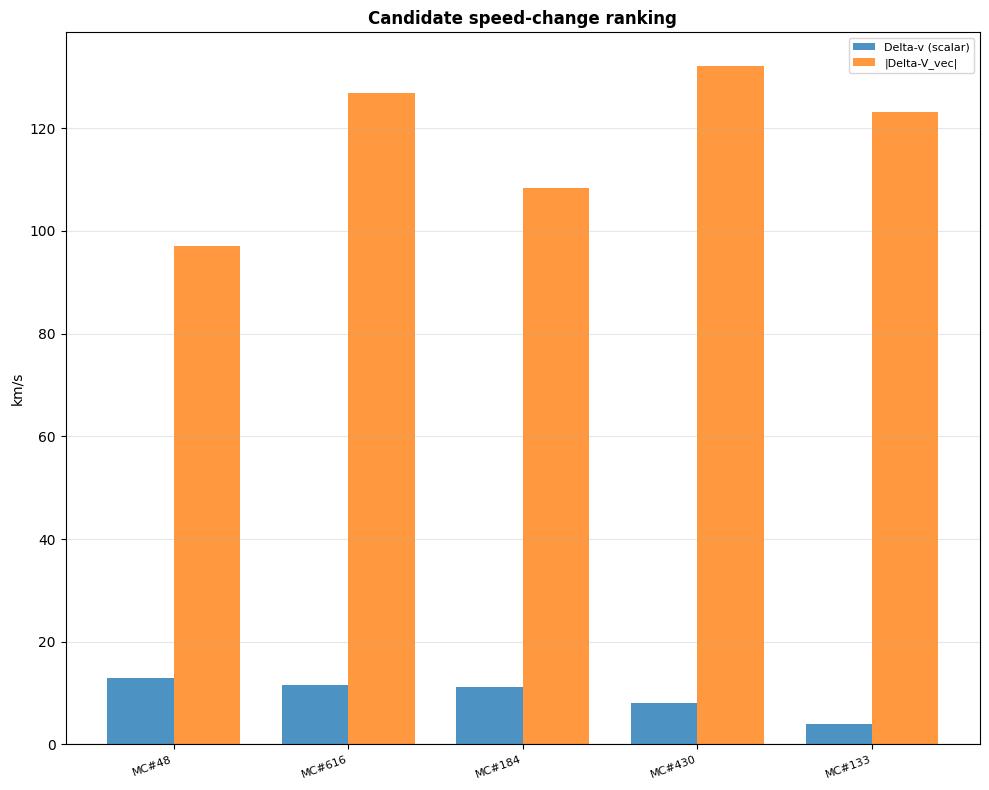

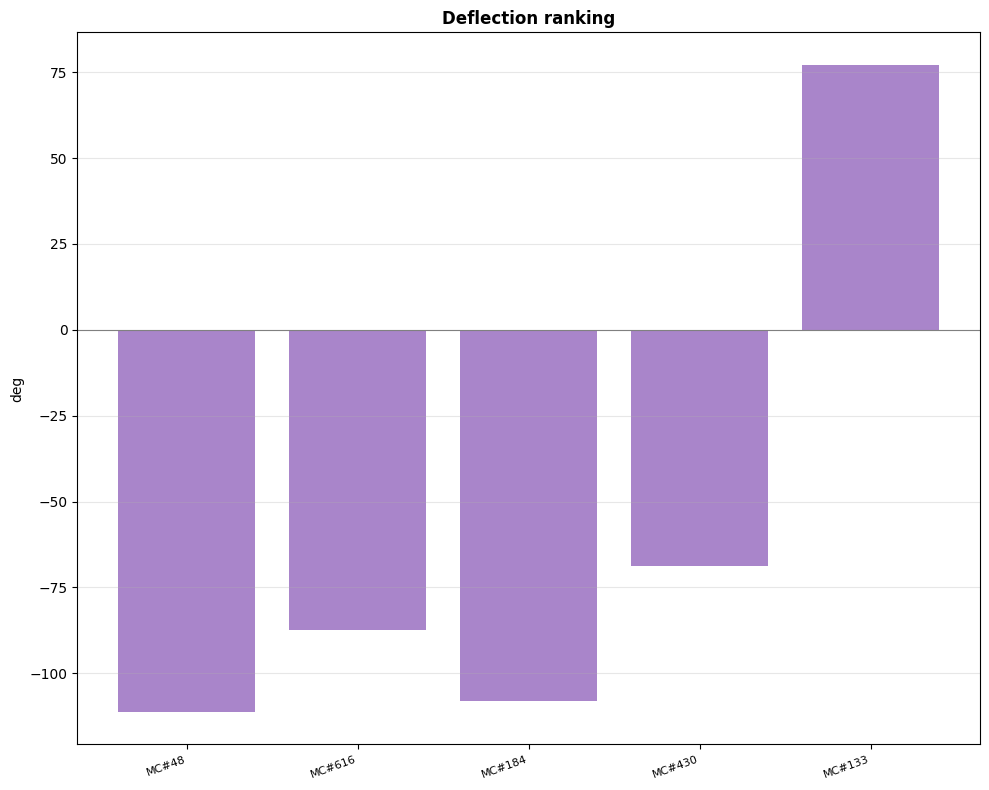

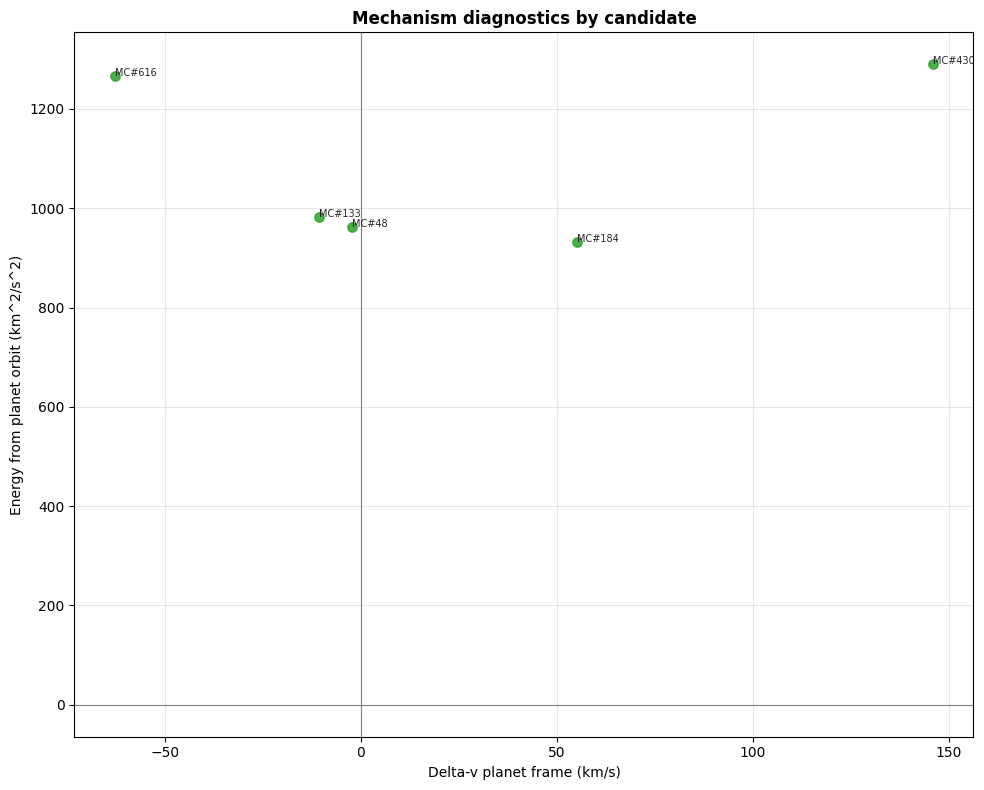

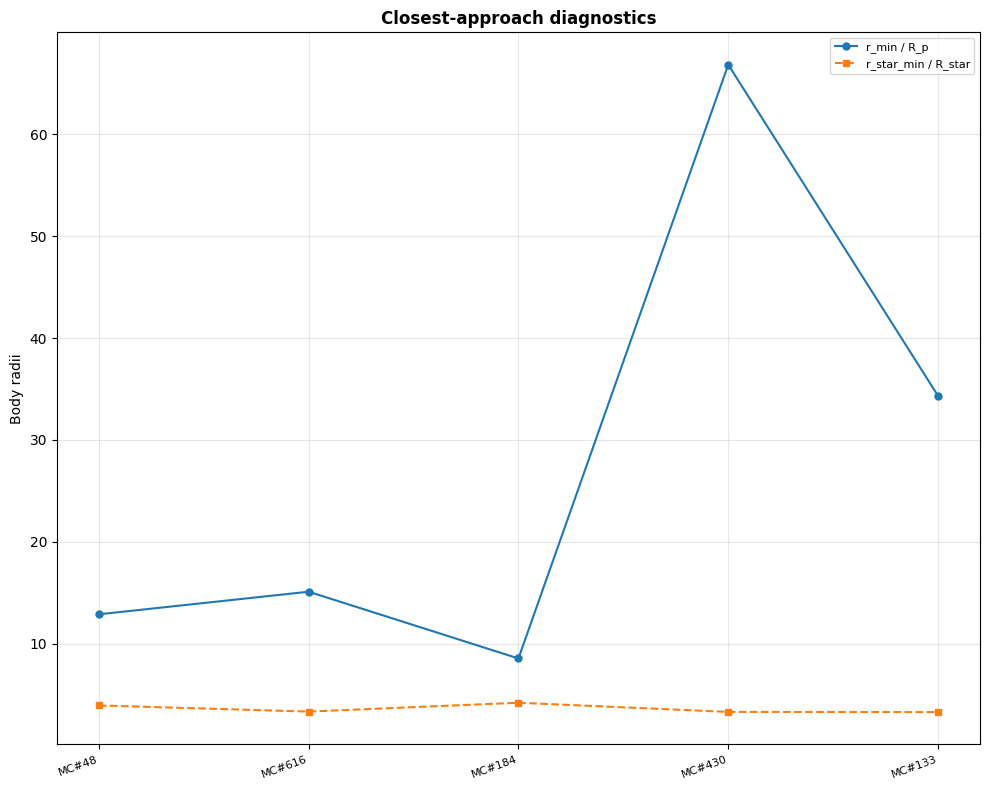

In [16]:
# Candidate ranking — individual panels (conditional on config flag)
if cfg.visualization.generate_candidate_ranking_plot:
    save_and_show_dict(
        plot_candidate_ranking_diagnostics_individual(
            analyses=analyses_best,
            top_indices=top_idx,
            R_p_km=R_p,
            R_star_km=R_star_km,
            figsize=LANDSCAPE_SIZE,
        ),
        output_dir, saved_plots,
    )
else:
    print("  Candidate ranking plot disabled in config")

### Baseline Comparison

Compare best 3-body candidate with 2-body hyperbola and monopole baselines.

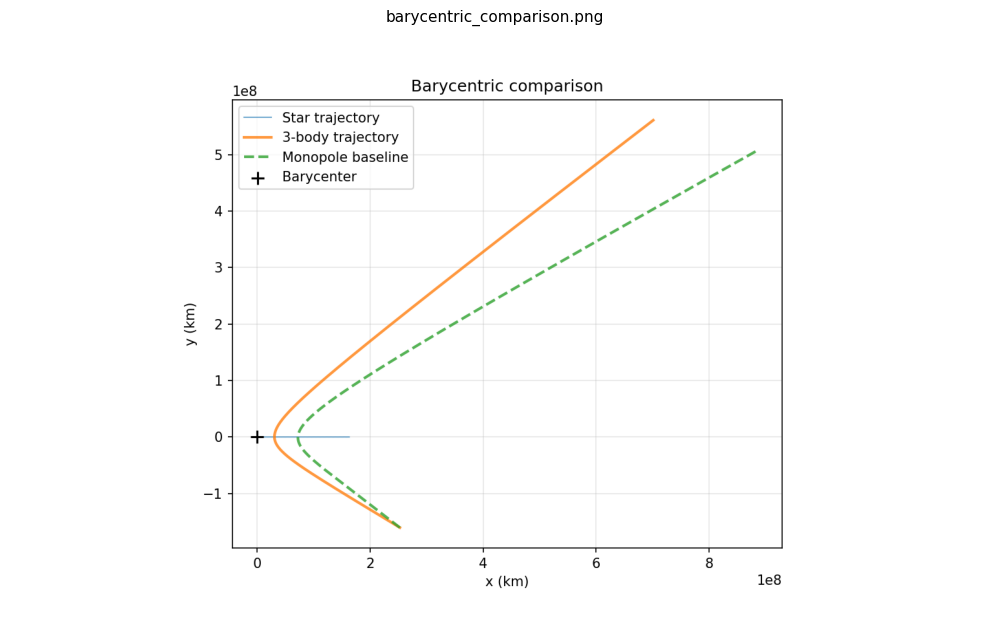

  ✓ barycentric_comparison.png


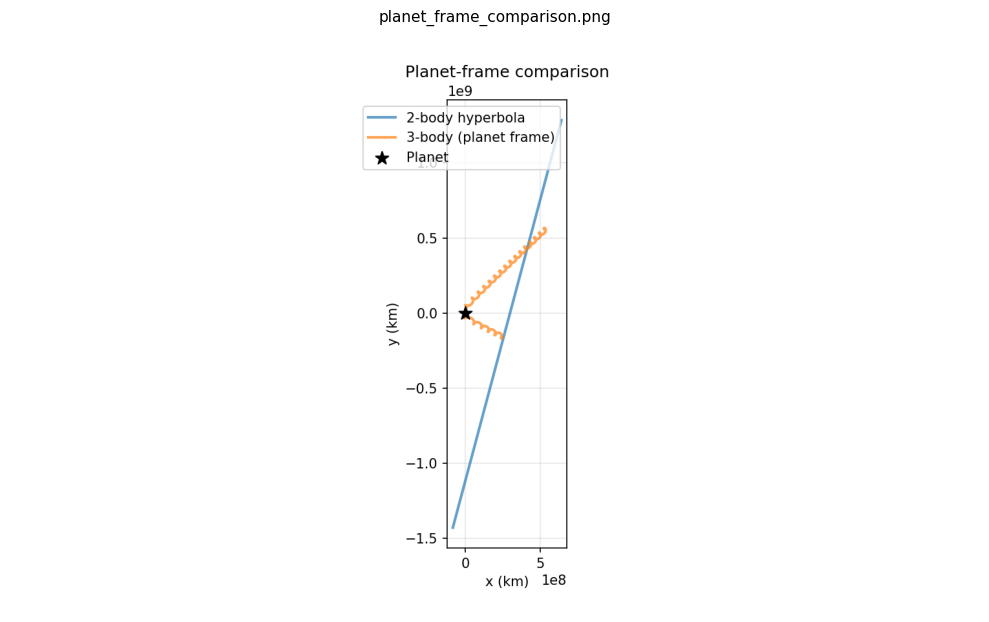

  ✓ planet_frame_comparison.png

Baseline Comparison Results:
  2-body deflection (planet hyperbola): 0.0°
  3-body deflection (barycentric):      110.1°
  Extra Δε from planet presence:        1.225e+02 km²/s²
  2-body periapsis:  288238313 km  (3490.7 R_p)
  2-body eccentricity:  4204.49


In [17]:
from slingshot.analysis.trajectory import extract_encounter_states

# Extract encounter geometry
enc = extract_encounter_states(
    best_sol,
    m_p=m_p,
    R_p=R_p,
    r_far_factor=cfg.numerical.r_far_factor,
    min_clearance_factor=cfg.numerical.min_clearance_factor,
)

if enc.ok:
    before_png = {p.name for p in output_dir.glob("*.png")}

    # Compare with baselines (generates baseline_comparison.png etc.)
    comparison = compare_3body_with_baselines(
        best_sol,
        enc,
        m_star=m_star,
        m_p=m_p,
        R_p=R_p,
        make_plots=True,
        plot_save_dir=str(output_dir),
    )

    # Display any newly-created PNGs
    after_png = {p.name for p in output_dir.glob("*.png")}
    for new_name in sorted(after_png - before_png):
        p = output_dir / new_name
        saved_plots.append(str(p))
        img = plt.imread(str(p))
        fig, ax = plt.subplots(figsize=LANDSCAPE_SIZE)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(new_name, fontsize=11)
        fig.tight_layout()
        display(fig)
        plt.close(fig)
        print(f"  ✓ {new_name}")

    if comparison["ok"]:
        tb = comparison["two_body"]
        print(f"\nBaseline Comparison Results:")
        print(f"  2-body deflection (planet hyperbola): {tb['deflection_deg']:.1f}°")
        print(f"  3-body deflection (barycentric):      {comparison['deflection_3body']:.1f}°")
        print(f"  Extra Δε from planet presence:        {comparison['extra_eps_from_planet']:.3e} km²/s²")
        if tb['hyperbolic']:
            print(f"  2-body periapsis:  {tb['r_p']:.0f} km  ({tb['r_p']/R_p:.1f} R_p)")
            print(f"  2-body eccentricity:  {tb['e']:.2f}")
else:
    print(f"Encounter extraction failed: {enc.reason}")

### Animation/Video Generation

Create animation frames for visual analysis.

In [18]:
if cfg.visualization.render_video:
    frames_dir = str(output_dir / "frames")
    print(f"Generating animations...")
    print(f"  Output dir: {frames_dir}")
    print(f"  Format: {cfg.visualization.video_format}")
    print(f"  FPS: {cfg.visualization.video_fps}")

    animations = generate_all_animations(
        best_sol,
        output_dir=frames_dir,
        video_fps=cfg.visualization.video_fps,
        video_format=cfg.visualization.video_format,
        animate_trajectory=cfg.visualization.animate_trajectory,
        animate_phase_space=cfg.visualization.animate_phase_space,
    )

    for anim_type, filepath in animations.items():
        if filepath:
            print(f"  ✓ {anim_type}: {filepath}")
        else:
            print(f"  ✗ {anim_type}: Failed")
else:
    print("Video rendering disabled in config.")

Video rendering disabled in config.


## Exploratory Analysis: All Candidates

In [19]:
# Create comparison table of all re-run candidates — styled display
from slingshot.output.notebook_display import (
    candidates_dataframe,
    styled_candidates_table,
)

# Build DataFrame with tier info (if tiers annotated)
df = candidates_dataframe(analyses_best, top_idx, top_n=len(top_idx))
print(f"\nTop Candidates Summary ({len(df)} candidates):")
display(styled_candidates_table(analyses_best, top_idx, top_n=len(top_idx)))


Top Candidates Summary (5 candidates):


Rank,MC#,Δv (km/s),Δv (%),|ΔV_vec| (km/s),½|ΔV|² (km²/s²),Deflection (°),r_min planet (km),r_min star (km),Tier,ε/Δε ratio
1,48,12.949,24.840,97.045,4708.910,-111.300,1065388.000,11204565.000,,—
2,616,11.631,13.550,126.830,8042.923,-87.400,1248310.000,9500238.000,,—
3,184,11.207,18.320,108.351,5869.983,-108.200,707713.000,11949757.000,,—
4,430,7.993,7.090,132.056,8719.372,-68.700,5516603.000,9409110.000,,—
5,133,4.052,4.200,123.052,7570.861,77.200,2834708.000,9356625.000,,—


## Save Configuration & Results

Store configuration and results for reproducibility.

In [20]:
from slingshot.config import save_config
import pickle
import dataclasses

# output_dir was already created after the MC cell — reuse it
print(f"Saving to: {output_dir}")

# Save config
config_file = output_dir / "config.yaml"
save_config(cfg, str(config_file), format="yaml")
print(f"✓ Config saved: {config_file}")

# Deep-convert dataclass instances to plain dicts (avoids PicklingError after importlib.reload)
def _strip_dataclasses(obj):
    if dataclasses.is_dataclass(obj) and not isinstance(obj, type):
        return {k: _strip_dataclasses(v) for k, v in dataclasses.asdict(obj).items()}
    if isinstance(obj, dict):
        return {k: _strip_dataclasses(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_strip_dataclasses(v) for v in obj]
    return obj

# Save results (including comparison — matching pipeline)
results_file = output_dir / "results.pkl"
with open(results_file, 'wb') as f:
    pickle.dump(_strip_dataclasses({
        'mc': mc,
        'top_indices': top_idx,
        'sols_best': sols_best,
        'analyses_best': analyses_best,
        'comparison': comp if 'comp' in dir() else None,
    }), f)
print(f"✓ Results saved: {results_file}")

# Save summary table
summary_file = output_dir / "summary.csv"
df.to_csv(summary_file, index=False)
print(f"✓ Summary saved: {summary_file}")

print(f"\nAll outputs in: {output_dir}")

Saving to: results\results_Kepler-432_20260308_211601
✓ Config saved: results\results_Kepler-432_20260308_211601\config.yaml
✓ Results saved: results\results_Kepler-432_20260308_211601\results.pkl
✓ Summary saved: results\results_Kepler-432_20260308_211601\summary.csv

All outputs in: results\results_Kepler-432_20260308_211601


## Phase 5: Cross-Solver Comparison — Narrowed Baselines (v2.2)

Run the closed-form 2-body baselines using **velocity-matched** parameter envelopes
derived from the top 3-body candidates.  This ensures the 2-body ceilings are computed
at the same approach speeds the 3-body solver actually explored, eliminating the
v_approach mismatch from v2.1.

**Pipeline:**
1. Extract encounter parameters (v_approach, b, angle, vstar0) from top 3-body analyses
2. Pad ranges by a configurable factor (default 1.5×)
3. Sweep TwoBodyScatter over the padded envelope for both star and planet scattering
4. Compare using **both** ε (specific orbital energy) and **|ΔV_vec|** (vector ΔV magnitude)

In [21]:
# Reload slingshot modules (ensures latest code is picked up)
import importlib
import slingshot.config, slingshot.analysis.comparison, slingshot.analysis.trajectory, slingshot.core.twobody
importlib.reload(slingshot.analysis.trajectory)
importlib.reload(slingshot.core.twobody)
importlib.reload(slingshot.config)
importlib.reload(slingshot.analysis.comparison)

# Force reload narrowed_baselines (new module)
import slingshot.analysis.narrowed_baselines
importlib.reload(slingshot.analysis.narrowed_baselines)

from slingshot.analysis.narrowed_baselines import compute_narrowed_baselines
from slingshot.analysis.comparison import compare_2body_3body, print_comparison

# --- Re-analyze top candidates with updated analysis.py ---
from slingshot.analysis.trajectory import analyze_trajectory
from slingshot.constants import R_SUN

# Star filter threshold for re-analysis
R_star_km = cfg.system.R_star_Rsun * R_SUN
star_clearance_Rstar = cfg.numerical.star_min_clearance_Rstar
star_clearance_km = star_clearance_Rstar * R_star_km if star_clearance_Rstar is not None else None

analyses_best_v2 = []
star_filtered_v2 = 0
for sol in sols_best:
    ana_v2 = analyze_trajectory(
        sol, frame="barycentric",
        m_star=m_star, m_p=m_p, R_p=R_p,
        r_far_factor=cfg.numerical.r_far_factor,
        min_clearance_factor=cfg.numerical.min_clearance_factor,
    )
    # Apply star filter
    if ana_v2 is not None and star_clearance_km is not None:
        enc_v2_chk = ana_v2.get("encounter")
        if enc_v2_chk is not None and enc_v2_chk.r_star_min is not None:
            if enc_v2_chk.r_star_min < star_clearance_km:
                ana_v2 = None
                star_filtered_v2 += 1
    analyses_best_v2.append(ana_v2)

valid_count = sum(1 for a in analyses_best_v2 if a is not None)
print(f"Re-analyzed {len(sols_best)} top candidates → {valid_count} valid (v2.3 fields)")
if star_filtered_v2 > 0:
    print(f"  Star-proximity filtered: {star_filtered_v2}")

# Best by scalar Δv (primary metric for interstellar slingshot)
valid_v2 = [(i, a) for i, a in enumerate(analyses_best_v2) if a is not None]
if not valid_v2:
    print("ERROR: No valid candidates after filtering!")
    best_ana_v2 = None
    best_vec_ana_v2 = None
else:
    best_local_idx_v2 = max(valid_v2, key=lambda x: x[1]["delta_v"])[0]
    best_ana_v2 = analyses_best_v2[best_local_idx_v2]
    best_original_idx = top_idx[best_local_idx_v2]

    # Best by ½|ΔV_vec|² (scattering energy)
    best_vec_idx_v2 = max(valid_v2, key=lambda x: x[1]["energy_half_dv_vec_sq"])[0]
    best_vec_ana_v2 = analyses_best_v2[best_vec_idx_v2]

    print(f"\nBest by scalar Δv (MC#{best_original_idx}):")
    print(f"  delta_v (scalar |v_f|-|v_i|)  = {best_ana_v2['delta_v']:.4f} km/s")
    print(f"  delta_v_vec (|v_f - v_i|)     = {best_ana_v2['delta_v_vec']:.4f} km/s")
    print(f"  energy ½|ΔV_vec|²             = {best_ana_v2['energy_half_dv_vec_sq']:.4f} km²/s²")
    # Planet-frame diagnostics
    dvpf = best_ana_v2.get('delta_v_planet_frame', None)
    if dvpf is not None:
        print(f"  Δv planet frame               = {dvpf:.4f} km/s")
        print(f"  ε from planet orbit            = {best_ana_v2.get('energy_from_planet_orbit', float('nan')):.4e} km²/s²")

    print(f"\nBest by ½|ΔV_vec|² (MC#{top_idx[best_vec_idx_v2]}):")
    print(f"  delta_v (scalar |v_f|-|v_i|)  = {best_vec_ana_v2['delta_v']:.4f} km/s")
    print(f"  delta_v_vec (|v_f - v_i|)     = {best_vec_ana_v2['delta_v_vec']:.4f} km/s")
    print(f"  energy ½|ΔV_vec|²             = {best_vec_ana_v2['energy_half_dv_vec_sq']:.4f} km²/s²")
    print(f"  deflection                    = {best_vec_ana_v2['deflection']:.1f}°")
    enc_v2 = best_vec_ana_v2["encounter"]
    if enc_v2.star_v_bary_in is not None:
        print(f"  star v_bary at encounter      = {np.linalg.norm(enc_v2.star_v_bary_in):.4f} km/s")
    r_star_v2 = enc_v2.r_star_min if enc_v2 and enc_v2.r_star_min is not None else float('nan')
    print(f"  r_min (star)                  = {r_star_v2:.0f} km ({r_star_v2/R_star_km:.1f} R★)")

Re-analyzed 5 top candidates → 5 valid (v2.3 fields)

Best by scalar Δv (MC#48):
  delta_v (scalar |v_f|-|v_i|)  = 12.9487 km/s
  delta_v_vec (|v_f - v_i|)     = 97.0455 km/s
  energy ½|ΔV_vec|²             = 4708.9102 km²/s²
  Δv planet frame               = -2.1005 km/s
  ε from planet orbit            = 9.6203e+02 km²/s²

Best by ½|ΔV_vec|² (MC#430):
  delta_v (scalar |v_f|-|v_i|)  = 7.9934 km/s
  delta_v_vec (|v_f - v_i|)     = 132.0558 km/s
  energy ½|ΔV_vec|²             = 8719.3717 km²/s²
  deflection                    = -68.7°
  star v_bary at encounter      = 10.0102 km/s
  r_min (star)                  = 9409110 km (3.3 R★)


In [22]:
# --- Tier Classification ---
from slingshot.analysis.tiering import annotate_tiers, tier_candidates, tier_summary_stats
from slingshot.output.notebook_display import styled_tier_summary

# Annotate each analysis dict with 'tier' and 'tier_ratio' keys
annotate_tiers(analyses_best_v2,
               planet_threshold=cfg.tiering.planet_dominated_threshold,
               hybrid_threshold=cfg.tiering.hybrid_threshold)

# Also annotate the original analyses_best for the candidates table
annotate_tiers(analyses_best,
               planet_threshold=cfg.tiering.planet_dominated_threshold,
               hybrid_threshold=cfg.tiering.hybrid_threshold)

# Build tiered buckets and summary
tiered = tier_candidates(analyses_best_v2, top_idx)
tier_stats = tier_summary_stats(tiered)

for tier_name, entries in tiered.items():
    print(f"  {tier_name}: {len(entries)} candidates")

# Styled summary table
display(styled_tier_summary(tier_stats))

  planet-dominated: 5 candidates
  hybrid: 0 candidates
  star-dominated: 0 candidates


Tier,Count,Δv min,Δv median,Δv max,Ratio range,Top MC#
planet-dominated,5,4.052,11.207,12.949,3.88–72.09,48.000
hybrid,0,—,—,—,—,—
star-dominated,0,—,—,—,—,—


### Narrowed 2-Body Baselines (velocity-matched)

In [23]:
# --- Compute narrowed baselines from top 3-body candidates ---
# Filter to valid analyses only
valid_analyses = [a for a in analyses_best_v2 if a is not None]

narrowed = compute_narrowed_baselines(
    analyses_top=valid_analyses,
    cfg=cfg,
    padding_factor=1.5,
    num_v=20,
    num_b=100,
    num_angles=100,
)

# Store results for CDF — use ½|ΔV_vec|² (body-dependent scattering energy)
# NOT max_epsilon which is ½v∞² (body-independent approach KE)
E_star_narrowed   = narrowed["star"].max_energy_half_dv_vec_sq   if narrowed["star"]   else None
E_planet_narrowed = narrowed["planet"].max_energy_half_dv_vec_sq if narrowed["planet"] else None
dv_vec_star  = narrowed["star"].max_deltaV_vec   if narrowed["star"]   else None
dv_vec_planet = narrowed["planet"].max_deltaV_vec if narrowed["planet"] else None

# 3-body best metrics — use best-by-½|ΔV_vec|² candidate (not best-by-scalar-Δv)
E_3body = best_vec_ana_v2["energy_half_dv_vec_sq"] if best_vec_ana_v2 else 0.0
dv_vec_3body = best_vec_ana_v2["delta_v_vec"] if best_vec_ana_v2 else 0.0

Envelope (5 candidates, padding=1.5x):
  v_approach : [7.41, 244.66] km/s
  b          : [1.00e+00, 2.86e+07] km
  angle      : [-199.2°, -71.5°]
  vstar      : (10.00, -0.45) km/s  |v|=10.01 km/s
[star] Narrowed sweep: 20×100×100 = 200000 encounters …
  40000/200000 (200 valid) …
  80000/200000 (2300 valid) …
  120000/200000 (5500 valid) …
  160000/200000 (9300 valid) …
  200000/200000 (13500 valid) …
[star] Complete: 13500/200000 successful
[planet] Narrowed sweep: 20×100×100 = 200000 encounters …
  40000/200000 (9500 valid) …
  80000/200000 (21600 valid) …
  120000/200000 (34500 valid) …
  160000/200000 (47700 valid) …
  200000/200000 (61000 valid) …
[planet] Complete: 61000/200000 successful
  NARROWED BASELINE COMPARISON
  Parameter envelope derived from top 3-body candidates
Envelope (5 candidates, padding=1.5x):
  v_approach : [7.41, 244.66] km/s
  b          : [1.00e+00, 2.86e+07] km
  angle      : [-199.2°, -71.5°]
  vstar      : (10.00, -0.45) km/s  |v|=10.01 km/s
-----------

### Formal Comparison Table (ε + vector ΔV)

In [24]:
# Build unified comparison dict with both metrics
# Uses best-by-½|ΔV_vec|² candidate for the 3-body column
comp = compare_2body_3body(
    # ε = ½v∞² (approach KE) — now correctly using max_epsilon, not ½|ΔV|²
    energy_2body_star=narrowed["star"].max_epsilon if narrowed["star"] else None,
    energy_2body_planet=narrowed["planet"].max_epsilon if narrowed["planet"] else None,
    energy_3body=E_3body,
    # Scalar ΔV baselines (best achievable |v_f| - |v_i| from 2-body sweeps)
    dv_2body_star=dv_vec_star,    # star vector ΔV as upper bound
    dv_2body_planet=dv_vec_planet, # planet vector ΔV as upper bound
    dv_3body=best_vec_ana_v2["delta_v"] if best_vec_ana_v2 else None,
    # Vector ΔV
    dv_vec_2body_star=dv_vec_star,
    dv_vec_2body_planet=dv_vec_planet,
    dv_vec_3body=dv_vec_3body,
    envelope_summary=narrowed["envelope"].summary() if narrowed["envelope"] else None,
    baseline_mode="narrowed",
)
print_comparison(comp)

  2-BODY  vs  3-BODY  COMPARISON
  All energies in km²/s² ≡ MJ/kg

--- ½|ΔV_vec|²  (scattering energy, body-dependent) ---
  Star  2-body max ½|ΔV|²  : 27128.24 km²/s² (27128.24 MJ/kg)
  Planet 2-body max ½|ΔV|² : 3740.15 km²/s² (3740.15 MJ/kg)
  3-body best ½|ΔV|²       : 8719.37 km²/s² (8719.37 MJ/kg)

--- ε = ½v∞²  (approach KE — same for any body at same speed) ---
  Star  baseline ε  : 29928.31 km²/s² (29928.31 MJ/kg)
  Planet baseline ε : 29929.88 km²/s² (29929.88 MJ/kg)
  3-body best ε     : 8719.37 km²/s² (8719.37 MJ/kg)
------------------------------------------------------------

  ΔV scalar (3-body best) : 7.99 km/s
  ΔV improvement (planet)  : -78.50 km/s
  ΔV improvement (star)    : -224.94 km/s

--- Scalar ΔV (|v_f| - |v_i|) ---
  Star  2-body max scalar ΔV    : 232.93 km/s
  Planet 2-body max scalar ΔV   : 86.49 km/s
  3-body best scalar ΔV         : 7.99 km/s

--- Vector ΔV (|v_f - v_i|) ---
  Star  2-body max |ΔV_vec|  : 232.93 km/s
  Planet 2-body max |ΔV_vec| : 86.49

### Publication Objectives Dashboard

Six-panel research objective diagnostics: mechanism identification, high-velocity
coverage, baseline ceiling, energy–deflection trade-off, deflection distribution,
and stellar proximity — now with baseline comparison data.


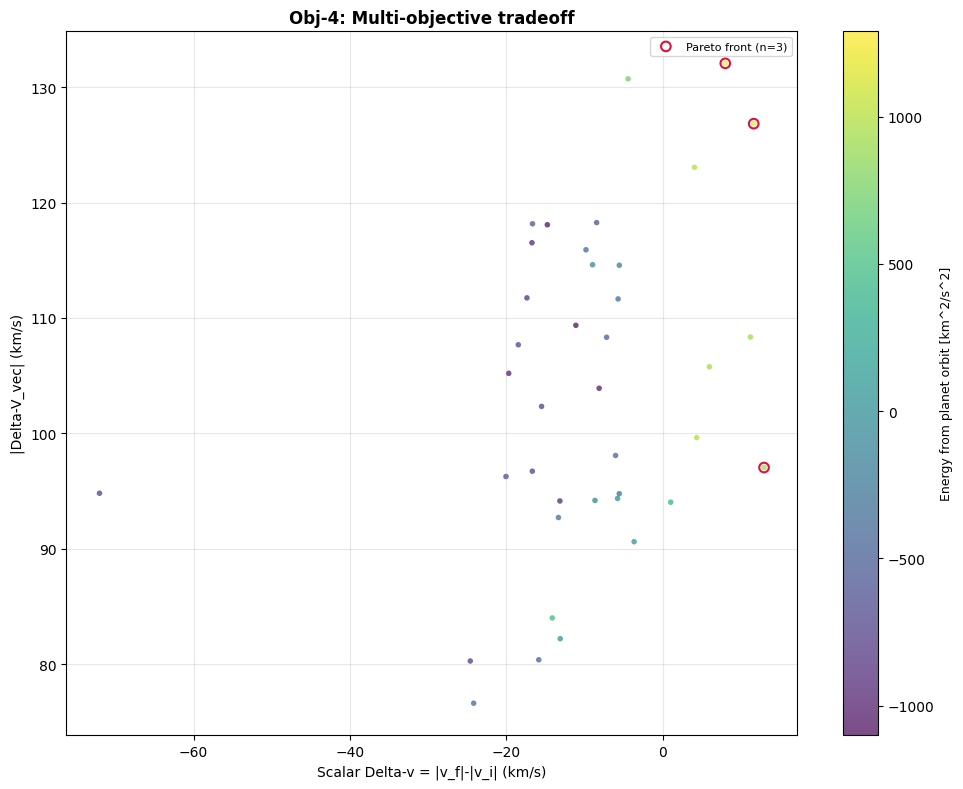

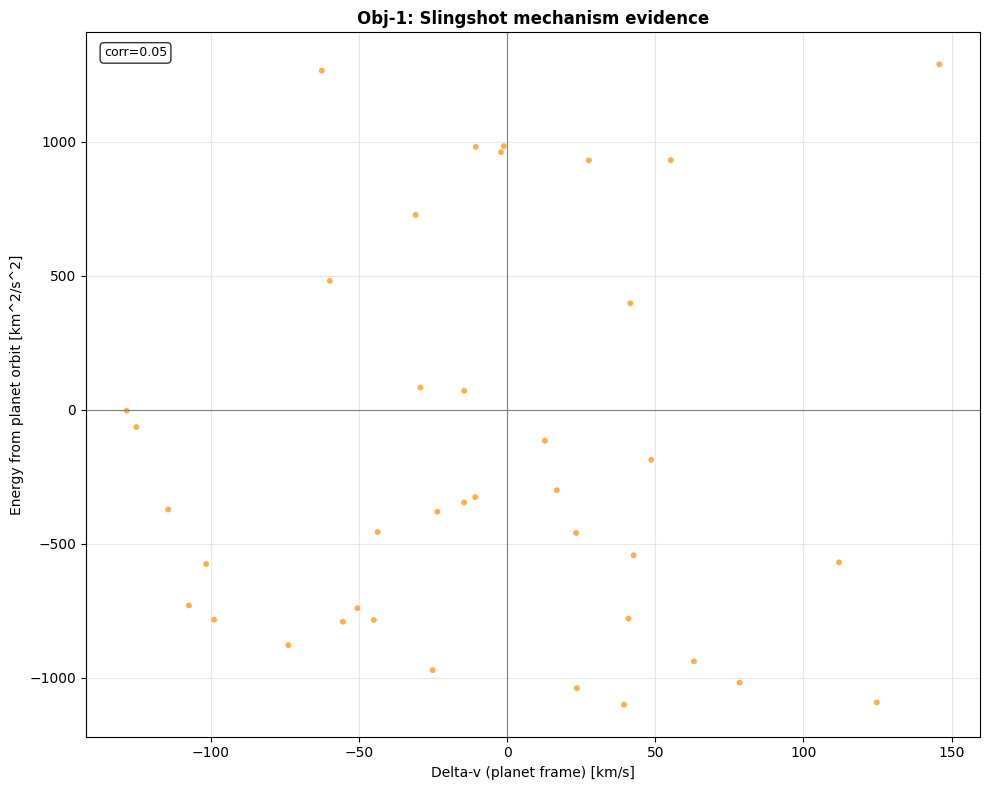

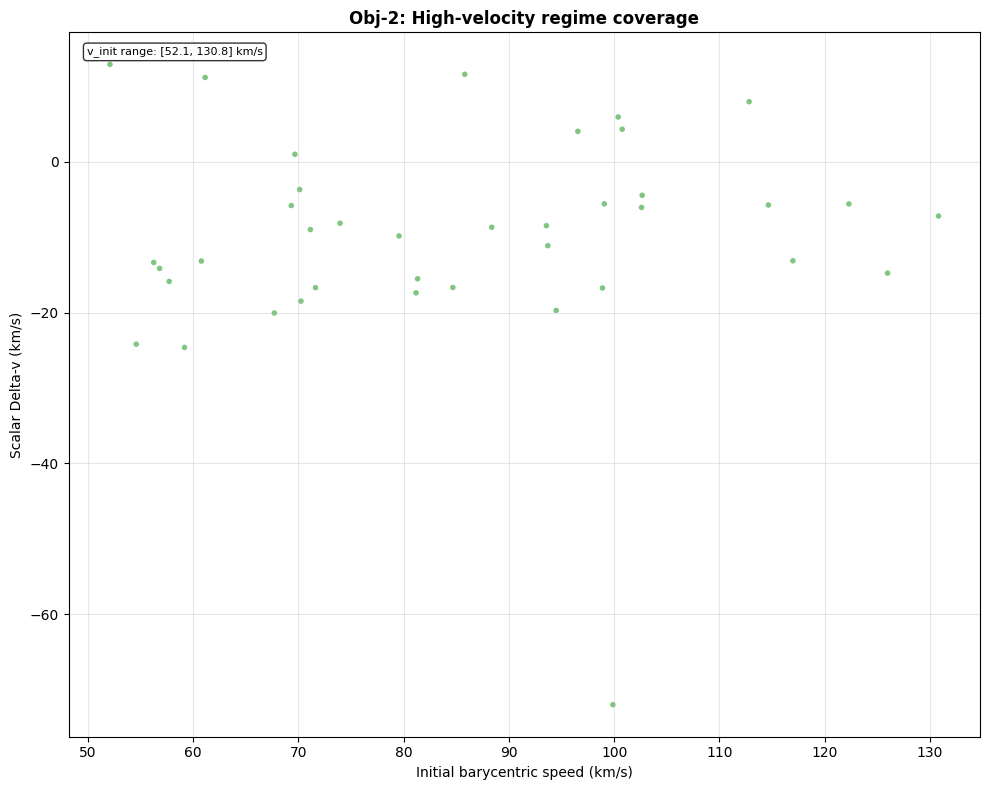

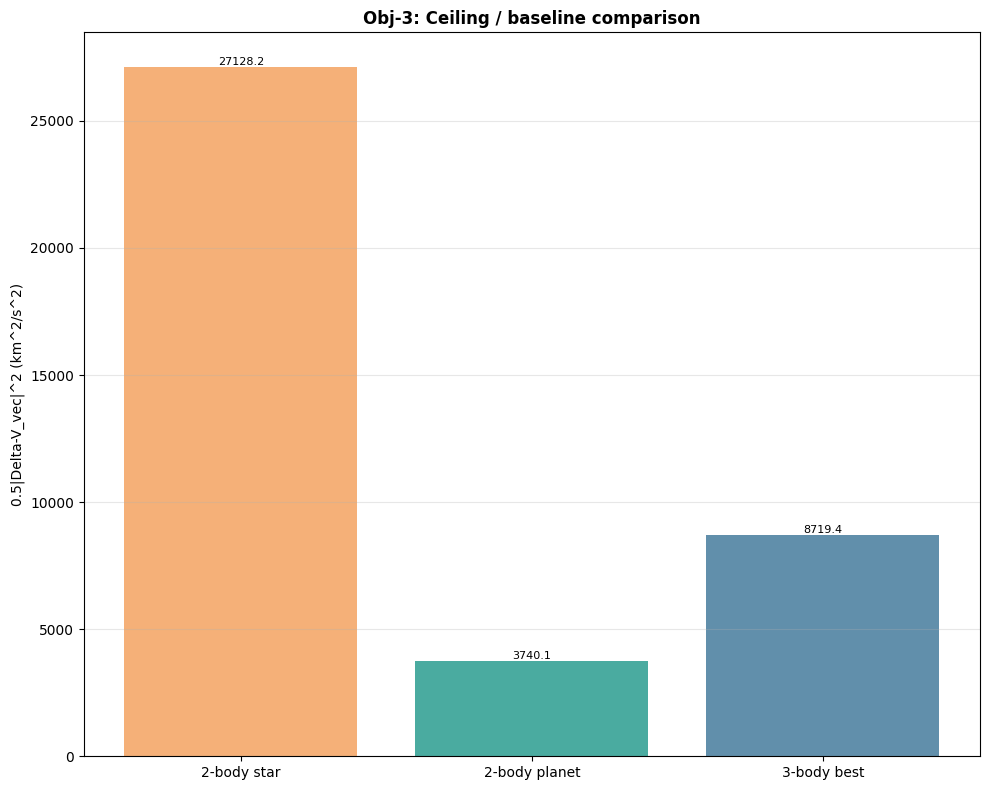

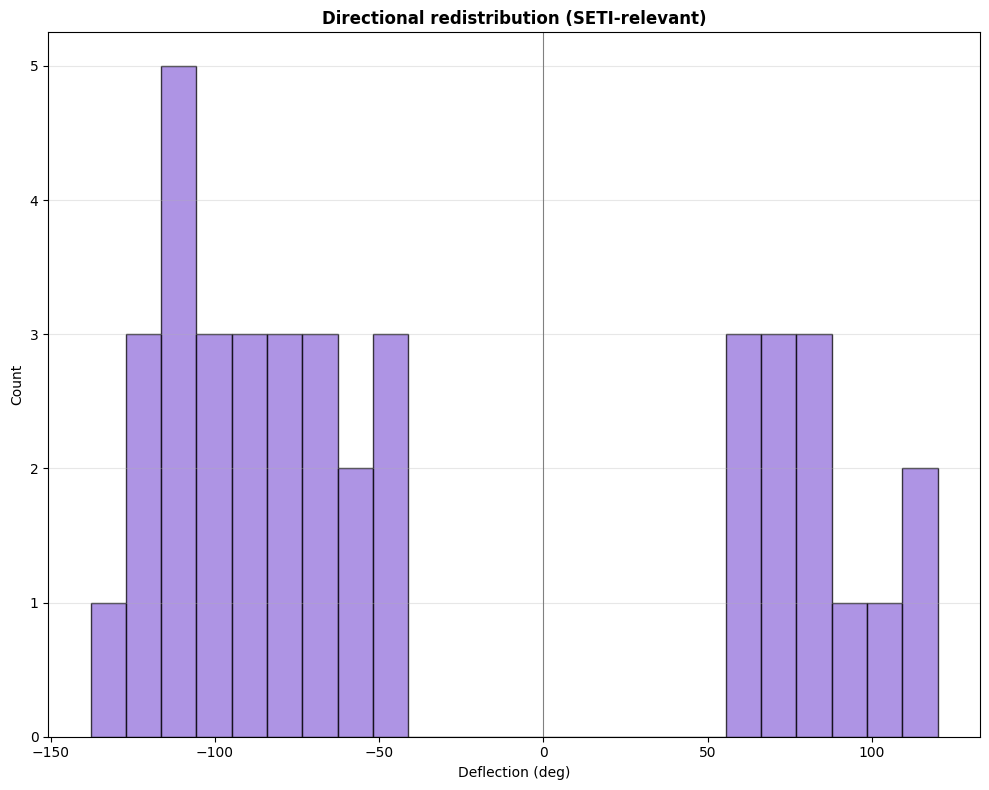

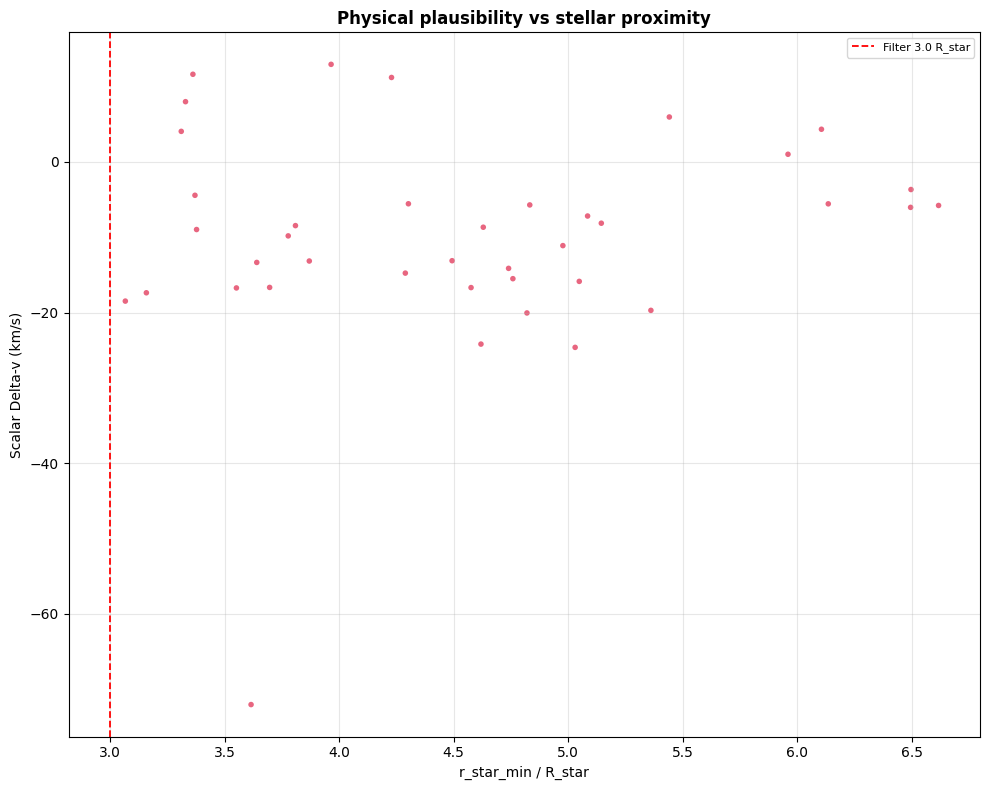

In [25]:
# Publication objectives dashboard — with baseline comparison data
valid_ana = [a for a in analyses_best_v2 if a is not None]
if cfg.visualization.generate_publication_dashboard:
    save_and_show_dict(
        plot_publication_objectives_individual(
            mc=mc,
            analyses_best=valid_ana if valid_ana else None,
            comparison=comp,
            R_star_km=R_star_km,
            clearance_Rstar=cfg.numerical.star_min_clearance_Rstar,
            figsize=LANDSCAPE_SIZE,
        ),
        output_dir, saved_plots,
    )
else:
    print("  Publication dashboard disabled in config")


### 2-Body Parameter-Space Heatmaps

Poincaré deflection/ΔV maps and encounter 2D Cartesian grids —
matching the pipeline's `plot_poincare_heatmaps`,
`plot_encounter_2d_cartesian`, and (optionally) `plot_oberth_comparison`.

In [26]:
from slingshot.output.plotting_twobody import (
    plot_poincare_heatmaps,
    plot_encounter_2d_cartesian,
    plot_oberth_comparison,
)

viz = cfg.visualization
res = viz.heatmap_grid_resolution
angles = viz.heatmap_approach_angles_deg

tb = cfg.two_body
v_app = tb.v_approach_kms if tb else 50.0

# Resolve 2-body star velocity — sync with narrowed envelope or 3-body init
narrowed_env = narrowed.get("envelope") if narrowed else None
if narrowed_env is not None and hasattr(narrowed_env, "vstar_vec"):
    vstar0 = (float(narrowed_env.vstar_vec[0]), float(narrowed_env.vstar_vec[1]))
    print(f"  2-body vstar sync: using narrowed-envelope value ({vstar0[0]:.3f}, {vstar0[1]:.3f}) km/s")
else:
    Y_sp0 = mc["Y_sp0"]
    vstar0 = (float(Y_sp0[2]), float(Y_sp0[3]))
    print(f"  2-body vstar sync: using 3-body init ({vstar0[0]:.3f}, {vstar0[1]:.3f}) km/s")

b_min = tb.b_min_km if tb else 1e7
b_max = tb.b_max_km if tb else 4e9

# --- Poincaré Heatmaps ---
if viz.generate_poincare_maps:
    print("Generating Poincaré heatmaps...")
    figs = plot_poincare_heatmaps(
        m_star, v_inf_kms=v_app, vstar0_kms=vstar0,
        num_b=res, num_angle=res,
        b_min_km=b_min, b_max_km=b_max,
        body_label=cfg.system.name + " Star",
        save_dir=output_dir, dpi=PLOT_DPI,
    )
    for fig in figs:
        # Already saved by save_dir; just display + close
        fig.set_size_inches(*LANDSCAPE_SIZE, forward=True)
        display(fig)
        plt.close(fig)
    # Capture saved filenames
    for p in sorted(output_dir.glob("poincare_heatmap_*.png")):
        if str(p) not in saved_plots:
            saved_plots.append(str(p))
    print(f"  ✓ poincare_heatmaps ({len(figs)} figs)")
else:
    print("  Poincaré heatmaps disabled")


# --- Encounter 2D Cartesian ---
if viz.generate_2body_heatmaps:
    print("Generating encounter 2D Cartesian maps...")
    figs = plot_encounter_2d_cartesian(
        m_star, v_approach_kms=v_app, vstar0_kms=vstar0,
        approach_angles_deg=angles, num_xy=res,
        body_label=cfg.system.name,
        save_dir=output_dir, dpi=PLOT_DPI,
    )
    for fig in figs:
        fig.set_size_inches(*LANDSCAPE_SIZE, forward=True)
        display(fig)
        plt.close(fig)
    for p in sorted(output_dir.glob("encounter_2d_*.png")):
        if str(p) not in saved_plots:
            saved_plots.append(str(p))
    print(f"  ✓ encounter_2d_cartesian ({len(figs)} figs)")
else:
    print("  Encounter 2D heatmaps disabled")

# --- Oberth Comparison (often disabled by default) ---
if viz.generate_oberth_maps:
    print("Generating Oberth comparison maps...")
    figs = plot_oberth_comparison(
        m_star, v_inf_kms=v_app, vstar0_kms=vstar0,
        num_b=res, num_angle=res,
        b_min_km=b_min, b_max_km=b_max,
        body_label=cfg.system.name,
        save_dir=output_dir, dpi=PLOT_DPI,
    )
    for fig in figs:
        fig.set_size_inches(*LANDSCAPE_SIZE, forward=True)
        display(fig)
        plt.close(fig)
    for p in sorted(output_dir.glob("oberth_*.png")):
        if str(p) not in saved_plots:
            saved_plots.append(str(p))
    print(f"  ✓ oberth_comparison ({len(figs)} figs)")
else:
    print("  Oberth maps disabled")

# --- 3-Body Poincaré Scatter (from actual MC integrations) ---
from slingshot.output.plotting_twobody import plot_3body_poincare_scatter

if viz.generate_poincare_maps:
    print("Generating 3-body Poincaré scatter maps...")
    figs_3b = plot_3body_poincare_scatter(
        mc, save_dir=output_dir, dpi=PLOT_DPI, figsize=LANDSCAPE_SIZE,
    )
    for fname, fig in figs_3b.items():
        fig.set_size_inches(*LANDSCAPE_SIZE, forward=True)
        display(fig)
        plt.close(fig)
    for p in sorted(output_dir.glob("poincare_3body_*.png")):
        if str(p) not in saved_plots:
            saved_plots.append(str(p))
    print(f"  \u2713 poincare_3body_scatter ({len(figs_3b)} figs)")
else:
    print("  3-body Poincaré scatter disabled")

  2-body vstar sync: using narrowed-envelope value (10.000, -0.452) km/s
  Poincaré heatmaps disabled
  Encounter 2D heatmaps disabled
  Oberth maps disabled
  3-body Poincaré scatter disabled


### 2-Body Trajectory Tracks — Star & Planet Baselines

Hyperbolic trajectories from fresh envelope-matched scans (150 b × 50 angles
per body) coloured by ½ΔV². 3-body candidate tracks overlaid in cyan.
Axes clamped to 3-body spatial extent + 20% padding.

In [27]:
import importlib
import slingshot.output.plotting_twobody
importlib.reload(slingshot.output.plotting_twobody)
from slingshot.output.plotting_twobody import plot_trajectory_tracks

viz = cfg.visualization

if not getattr(viz, "generate_trajectory_tracks", True):
    print("  Trajectory tracks disabled in config")
else:
    norm_mode = getattr(viz, "trajectory_energy_norm_mode", "auto")
    fixed_range = None
    if norm_mode == "fixed":
        vmin = getattr(viz, "trajectory_energy_vmin", None)
        vmax = getattr(viz, "trajectory_energy_vmax", None)
        if vmin is not None and vmax is not None and vmax > vmin:
            fixed_range = (float(vmin), float(vmax))

    figs_tt = plot_trajectory_tracks(
        narrowed=narrowed,
        sols_best=sols_best,
        analyses_best=analyses_best_v2,
        cfg=cfg,
        overlay_lines=getattr(viz, "trajectory_overlay_lines", True),
        overlay_line_count=getattr(viz, "trajectory_overlay_line_count", 90),
        gradient_mode=getattr(viz, "trajectory_gradient_mode", "hexbin"),
        confidence_min_count=getattr(viz, "trajectory_confidence_min_count", 2),
        fixed_energy_range=fixed_range,
        hexbin_gridsize=getattr(viz, "trajectory_hexbin_gridsize", 150),
        kde_sigma_bins=getattr(viz, "trajectory_kde_sigma_bins", 2.0),
        time_frames=getattr(viz, "trajectory_time_frames", 48),
        export_time_data=getattr(viz, "trajectory_time_export_npz", True),
        include_star=getattr(viz, "generate_star_trajectory_diagnostics", False),
        figsize=LANDSCAPE_SIZE,
        save_dir=str(output_dir),
        dpi=PLOT_DPI,
    )
    for fig in figs_tt:
        fig.set_size_inches(*LANDSCAPE_SIZE, forward=True)
        display(fig)
        plt.close(fig)


  Trajectory tracks disabled in config


### Energy CDF — Enriched (Narrowed Baselines + Re-run Overlay)

Cumulative distribution of 3-body MC energies (½|ΔV_vec|²) with narrowed 2-body
upper bounds and high-resolution re-run overlay — matching pipeline output.

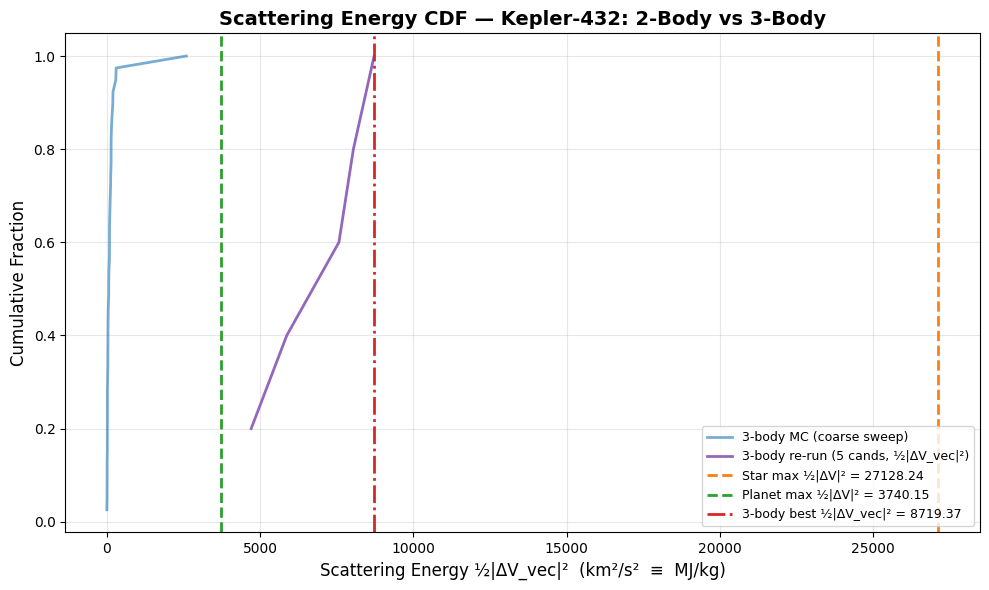


Coarse MC sweep (39 particles):
  Exceeding star  ½|ΔV|² bound: 0.0%
  Exceeding planet ½|ΔV|² bound: 0.0%

High-res re-runs (5 candidates, ½|ΔV_vec|²):
  Exceeding star  ½|ΔV|² bound: 0/5 (0.0%)
  Exceeding planet ½|ΔV|² bound: 5/5 (100.0%)


In [28]:
# Energy CDF — enriched with narrowed baselines + re-run overlay (matching pipeline)
cdf_kwargs = {}

# Narrowed 2-body baselines (½|ΔV_vec|²)
if E_star_narrowed is not None:
    cdf_kwargs["E_star_narrowed"] = E_star_narrowed
if E_planet_narrowed is not None:
    cdf_kwargs["E_planet_narrowed"] = E_planet_narrowed

# High-res re-run analyses overlay
valid_analyses_cdf = [a for a in analyses_best_v2 if a is not None]
if valid_analyses_cdf:
    cdf_kwargs["analyses_best"] = valid_analyses_cdf

# 3-body best (vector ΔV energy)
if best_vec_ana_v2:
    cdf_kwargs["E_3body_best"] = best_vec_ana_v2.get("energy_half_dv_vec_sq", None)

cdf_kwargs["system_name"] = cfg.system.name

save_and_show(
    plot_energy_cdf(mc, save_dir=None, dpi=PLOT_DPI, **cdf_kwargs),
    output_dir / "energy_cdf.png", saved_plots,
)

# Summary statistics
ok = mc["ok"]
energies_mc_coarse = 0.5 * mc["delta_v"][ok] ** 2
energies_rerun = np.array([
    a["energy_half_dv_vec_sq"] for a in analyses_best_v2 if a is not None
])

print(f"\nCoarse MC sweep ({len(energies_mc_coarse)} particles):")
if E_star_narrowed is not None:
    frac_above_star = (energies_mc_coarse > E_star_narrowed).sum() / len(energies_mc_coarse) * 100
    print(f"  Exceeding star  ½|ΔV|² bound: {frac_above_star:.1f}%")
if E_planet_narrowed is not None:
    frac_above_planet = (energies_mc_coarse > E_planet_narrowed).sum() / len(energies_mc_coarse) * 100
    print(f"  Exceeding planet ½|ΔV|² bound: {frac_above_planet:.1f}%")

print(f"\nHigh-res re-runs ({len(energies_rerun)} candidates, ½|ΔV_vec|²):")
if E_star_narrowed is not None:
    n_above = (energies_rerun > E_star_narrowed).sum()
    print(f"  Exceeding star  ½|ΔV|² bound: {n_above}/{len(energies_rerun)} "
          f"({n_above/len(energies_rerun)*100:.1f}%)")
if E_planet_narrowed is not None:
    n_above = (energies_rerun > E_planet_narrowed).sum()
    print(f"  Exceeding planet ½|ΔV|² bound: {n_above}/{len(energies_rerun)} "
          f"({n_above/len(energies_rerun)*100:.1f}%)")

## Phase 6: Uncertainty Propagation

Propagate parameter posteriors (stellar mass, planet mass, orbital radius) through the
top candidates to compute confidence intervals on all slingshot metrics.
Also run bootstrap Pareto stability to measure how consistently each candidate
appears on the non-dominated front under resampling.

In [29]:
# --- 6a. Parameter-Posterior Monte Carlo ---
# Build parameter distributions from config (or use defaults for Kepler-432)
if cfg.uncertainty is not None and cfg.uncertainty.enabled:
    param_dists = {
        k: {"mean": v.mean, "std": v.std}
        for k, v in cfg.uncertainty.parameters.items()
    }
    unc_seed = cfg.uncertainty.seed or 99

    print("Running parameter-posterior MC …")
    posterior_df = run_parameter_posterior_mc(
        base_cfg=cfg,
        mc_results=mc,
        top_indices=top_idx,
        n_draws=cfg.uncertainty.n_draws,
        seed=unc_seed,
        param_dists=param_dists,
    )
    print(f"  ✓ {len(posterior_df)} posterior draws ({cfg.uncertainty.n_draws} × {len(top_idx)} candidates)")

    # Confidence bands — styled display
    ci_bands = compute_confidence_bands(posterior_df, ci_levels=[0.68, 0.95])
    print(f"\n68%/95% Confidence Intervals (per candidate):")
    from slingshot.output.notebook_display import styled_uncertainty_table
    tier_lookup = {int(top_idx[i]): a.get("tier", "") for i, a in enumerate(analyses_best_v2) if a and i < len(top_idx)}
    display(styled_uncertainty_table(ci_bands, tier_lookup=tier_lookup))

else:
    print("Uncertainty propagation disabled in config (uncertainty.enabled=false).")
    print("Enable it in the YAML or set cfg.uncertainty = UncertaintyConfig(enabled=True, ...)")
    posterior_df = None
    ci_bands = None

Running parameter-posterior MC …
  Uncertainty draw 1/50
  Uncertainty draw 6/50
  Uncertainty draw 11/50
  Uncertainty draw 16/50
  Uncertainty draw 21/50
  Uncertainty draw 26/50
  Uncertainty draw 31/50
  Uncertainty draw 36/50
  Uncertainty draw 41/50
  Uncertainty draw 46/50
  ✓ 250 posterior draws (50 × 5 candidates)

68%/95% Confidence Intervals (per candidate):


candidate_mc_idx,Tier,n_draws,delta_v_median,delta_v_mean,delta_v_std,delta_v_lo68,delta_v_hi68,delta_v_lo95,delta_v_hi95,delta_v_vec_median,delta_v_vec_mean,delta_v_vec_std,delta_v_vec_lo68,delta_v_vec_hi68,delta_v_vec_lo95,delta_v_vec_hi95,energy_half_dv_vec_sq_median,energy_half_dv_vec_sq_mean,energy_half_dv_vec_sq_std,energy_half_dv_vec_sq_lo68,energy_half_dv_vec_sq_hi68,energy_half_dv_vec_sq_lo95,energy_half_dv_vec_sq_hi95,deflection_median,deflection_mean,deflection_std,deflection_lo68,deflection_hi68,deflection_lo95,deflection_hi95,delta_v_planet_frame_median,delta_v_planet_frame_mean,delta_v_planet_frame_std,delta_v_planet_frame_lo68,delta_v_planet_frame_hi68,delta_v_planet_frame_lo95,delta_v_planet_frame_hi95,energy_from_planet_orbit_median,energy_from_planet_orbit_mean,energy_from_planet_orbit_std,energy_from_planet_orbit_lo68,energy_from_planet_orbit_hi68,energy_from_planet_orbit_lo95,energy_from_planet_orbit_hi95
48,planet-dominated,50,11.815,11.071,3.344,9.498,12.922,-0.080,15.208,97.287,97.287,0.989,96.684,98.239,94.774,98.752,4732.419,4732.896,95.680,4673.948,4825.429,4491.097,4875.949,-114.419,-115.164,6.830,-117.542,-110.728,-138.294,-106.666,38.783,21.629,38.857,-27.192,61.127,-44.124,66.431,968.660,966.266,14.246,958.698,979.162,929.549,985.549
133,planet-dominated,50,4.728,2.159,12.001,-0.052,8.514,-39.434,12.725,122.304,122.044,9.630,119.818,134.014,98.453,135.261,7479.086,7493.730,1123.135,7178.207,8979.928,4849.543,9147.826,77.319,77.140,4.807,74.590,81.974,67.722,83.283,-60.665,-78.177,59.337,-149.259,-15.286,-177.948,-3.555,986.308,959.703,121.356,934.537,1043.988,564.048,1082.518
184,planet-dominated,50,9.893,10.010,3.792,9.284,11.539,2.433,15.517,107.634,106.224,8.049,107.189,108.833,86.268,114.342,5792.492,5674.181,815.958,5744.717,5922.324,3721.151,6537.232,-108.366,-106.670,7.441,-109.986,-107.919,-112.341,-83.445,2.938,-7.307,50.136,-70.281,49.905,-79.553,55.168,929.779,911.419,95.118,924.732,945.870,630.245,992.029
430,planet-dominated,50,7.957,7.684,0.892,7.651,7.986,5.860,7.998,132.397,132.690,4.354,128.888,136.140,124.031,140.970,8764.437,8812.769,580.383,8306.121,9267.104,7693.503,9936.422,-68.945,-69.263,2.862,-71.285,-66.878,-74.984,-64.094,141.378,119.889,52.737,59.724,171.826,7.944,175.950,1292.492,1293.065,32.894,1263.527,1321.574,1221.786,1351.626
616,planet-dominated,50,10.678,9.546,3.894,6.908,11.636,-0.947,13.585,126.967,123.745,7.767,115.358,128.776,104.514,129.647,8060.333,7686.602,905.636,6653.730,8291.626,5463.526,8404.129,-87.616,-85.970,4.600,-89.334,-80.430,-90.346,-75.491,67.257,42.654,60.232,-38.907,112.215,-62.813,116.357,1267.585,1235.172,78.994,1146.730,1286.098,1041.251,1296.246


In [30]:
# --- 6b. Bootstrap Pareto Stability ---
if cfg.uncertainty is not None and cfg.uncertainty.enabled and mode == "pareto":
    objectives = [
        {"metric": o.metric, "sign": o.sign, "weight": o.weight}
        for o in cfg.pipeline.selection_objectives
    ]
    n_boot = cfg.uncertainty.bootstrap_n_resample

    print(f"Bootstrap Pareto stability ({n_boot} resamples) …")
    boot_result = bootstrap_pareto_stability(
        mc,
        objectives=objectives,
        n_resample=n_boot,
        seed=unc_seed,
    )

    freq = boot_result["membership_freq"]
    stable = boot_result["stable_front"]
    print(f"  ✓ {len(freq)} unique front members across resamples")
    print(f"  Stable front (≥50% membership): {len(stable)} candidates")

    # Show top-10 most stable
    sorted_freq = sorted(freq.items(), key=lambda x: -x[1])[:10]
    for idx, f in sorted_freq:
        label = "★" if f >= 0.5 else " "
        print(f"    {label} MC#{idx:4d}: {f:.0%}")

else:
    boot_result = None
    if mode != "pareto":
        print("Bootstrap Pareto stability skipped (select_mode != 'pareto').")
    else:
        print("Bootstrap Pareto stability skipped (uncertainty disabled).")

Bootstrap Pareto stability (200 resamples) …
  ✓ 14 unique front members across resamples
  Stable front (≥50% membership): 3 candidates
    ★ MC# 616: 62%
    ★ MC# 430: 62%
    ★ MC#  48: 58%
      MC# 133: 43%
      MC# 184: 43%
      MC# 188: 26%
      MC# 354: 20%
      MC# 951: 20%
      MC# 813: 4%
      MC# 729: 3%


## Phase 7: Robustness & Sensitivity Analysis

Test numerical convergence (metric stability vs N) and sensitivity to numerical
parameters (Plummer softening, ODE tolerance, star clearance, flyby radius).
Produces publication-ready markdown and LaTeX tables.

In [31]:
# --- 7a. N-Convergence Test ---
convergence_df = None
sensitivity_df = None

rob_cfg = cfg.robustness if cfg.robustness is not None else None
rob_enabled = rob_cfg is not None and rob_cfg.enabled

if rob_enabled:
    metric_names = rob_cfg.metric_names or ["delta_v", "delta_v_vec", "deflection"]
    rob_seed = rob_cfg.seed or 42

    print("Running N-convergence test …")
    convergence_df = run_convergence_test(
        base_cfg=cfg,
        N_values=rob_cfg.convergence_N,
        seed=rob_seed,
        metric_names=metric_names,
    )
    print(f"\n{format_robustness_table(convergence_df, metric_names=metric_names, fmt='markdown')}")

    # Check convergence verdict
    conv_cols = [c for c in convergence_df.columns if c.startswith("converged_")]
    if len(convergence_df) >= 2:
        last_row = convergence_df.iloc[-1]
        all_converged = all(last_row[c] for c in conv_cols)
        print(f"\n  Verdict: {'✓ CONVERGED' if all_converged else '✗ NOT converged'} at N={int(last_row['N'])}")
else:
    print("Robustness analysis disabled in config (robustness.enabled=false).")
    print("Enable it in the YAML or set cfg.robustness = RobustnessConfig(enabled=True, ...)")

Robustness analysis disabled in config (robustness.enabled=false).
Enable it in the YAML or set cfg.robustness = RobustnessConfig(enabled=True, ...)


In [32]:
# --- 7b. Numerical Sensitivity Sweep ---
if rob_enabled:
    print("Running numerical sensitivity sweep …")
    sensitivity_df = run_numerical_sensitivity(
        base_cfg=cfg,
        seed=rob_seed,
        metric_names=metric_names,
        robustness_cfg=rob_cfg,
    )
    print(f"\n{format_robustness_table(sensitivity_df, metric_names=metric_names, fmt='markdown')}")

    # LaTeX version for the paper
    print("\n--- LaTeX Table ---")
    print(format_robustness_table(sensitivity_df, metric_names=metric_names, fmt="latex"))
else:
    print("Sensitivity sweep skipped (robustness disabled).")

Sensitivity sweep skipped (robustness disabled).


### Pareto Front & Trade-Off Plots

Visualise the Pareto front in objective space and the scalar-vs-vector Δv trade-off
(only meaningful when `select_mode = "pareto"`).

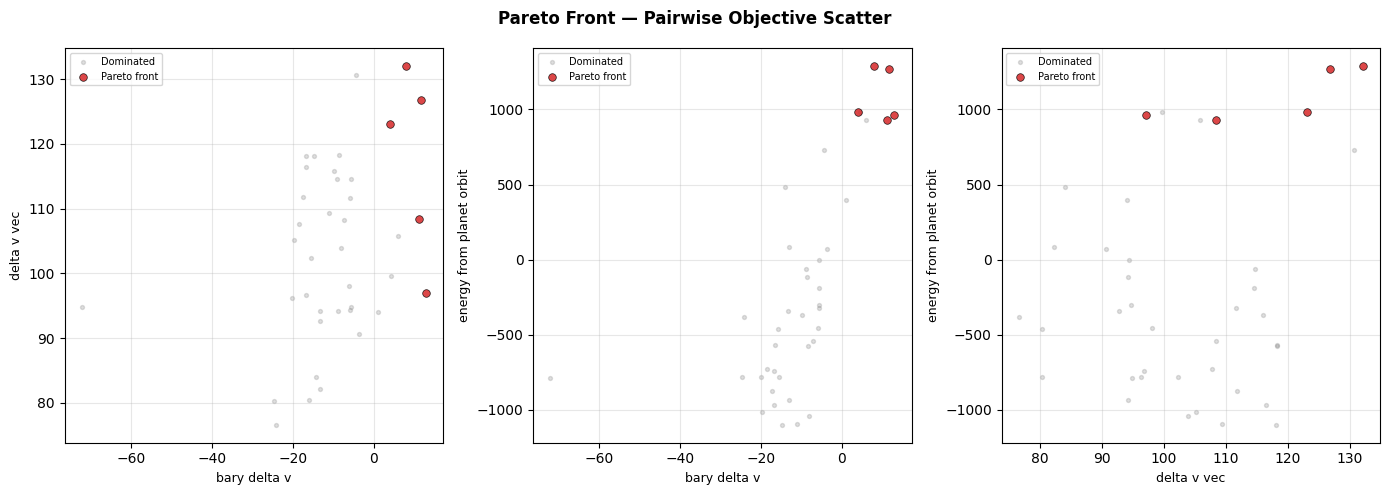

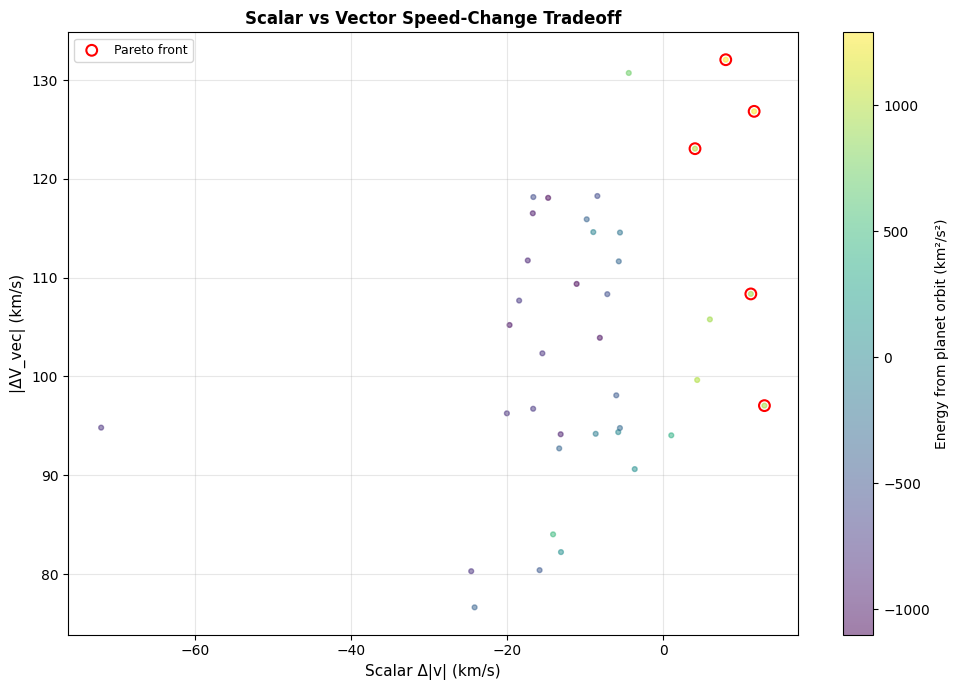

In [33]:
# Pareto front pairwise scatter (3-panel)
if mode == "pareto":
    objectives = [
        {"metric": o.metric, "sign": o.sign, "weight": o.weight}
        for o in cfg.pipeline.selection_objectives
    ]
    pareto_figs = plot_pareto_front_2d(mc, top_idx, objectives)
    save_and_show_dict(pareto_figs, output_dir, saved_plots)

    # Scalar-vs-vector Δv trade-off
    tradeoff_figs = plot_scalar_vs_vector_tradeoff(mc, top_idx)
    save_and_show_dict(tradeoff_figs, output_dir, saved_plots)
else:
    print("Pareto plots skipped (select_mode != 'pareto').")

### Uncertainty & Convergence Diagnostics

- **Uncertainty violin plots**: distribution of metrics across posterior draws per candidate
- **Convergence curves**: metric mean vs N with plateau detection
- **Sensitivity tornado**: % change in best-candidate metrics under parameter perturbations

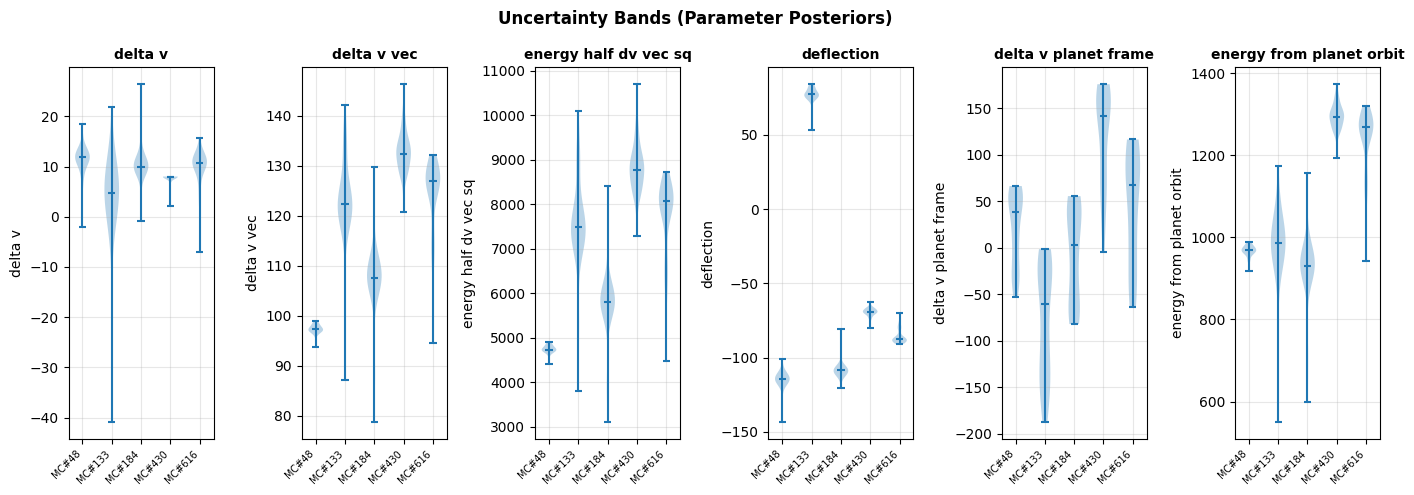

Convergence curves skipped (robustness disabled or empty).
Sensitivity tornado skipped (robustness disabled or empty).


In [34]:
# Uncertainty violin plots
if posterior_df is not None and len(posterior_df) > 0:
    unc_figs = plot_uncertainty_bands(posterior_df)
    save_and_show_dict(unc_figs, output_dir, saved_plots)
else:
    print("Uncertainty violin plots skipped (no posterior draws).")

# Convergence curves
if convergence_df is not None and len(convergence_df) > 0:
    conv_figs = plot_convergence_curves(convergence_df)
    save_and_show_dict(conv_figs, output_dir, saved_plots)
else:
    print("Convergence curves skipped (robustness disabled or empty).")

# Sensitivity tornado
if sensitivity_df is not None and len(sensitivity_df) > 0:
    metric_names_for_tornado = (rob_cfg.metric_names or ["delta_v", "delta_v_vec", "deflection"]) if rob_cfg else ["delta_v"]
    for m in metric_names_for_tornado:
        pct_col = f"pct_change_{m}"
        if pct_col in sensitivity_df.columns:
            tornado_figs = plot_sensitivity_tornado(sensitivity_df, m)
            save_and_show_dict(tornado_figs, output_dir, saved_plots)
else:
    print("Sensitivity tornado skipped (robustness disabled or empty).")

## Generate Report

Auto-generate `REPORT.md` with system parameters, MC statistics, best candidates,
2-body vs 3-body comparison, Pareto front analysis, uncertainty confidence intervals,
bootstrap stability, robustness/sensitivity tables, and all saved plot references —
matching the CLI pipeline output.

In [35]:
# Build the 'best' dict matching the pipeline convention
best_dict = {
    "best_ana": best_ana,
    "best_sol": best_sol,
    "best_idx": int(best_original_idx),
    "best_vec_ana": best_vec_ana_v2 if 'best_vec_ana_v2' in dir() else best_vec_ana,
    "best_vec_sol": best_vec_sol,
    "best_vec_idx": int(best_vec_original_idx),
}

# Assemble uncertainty results (matching pipeline convention)
uncertainty_results = None
if posterior_df is not None:
    uncertainty_results = {
        "posterior_df": posterior_df,
        "confidence_bands": ci_bands,
        "bootstrap": boot_result,
    }

# Assemble robustness results
robustness_results = None
if convergence_df is not None or sensitivity_df is not None:
    robustness_results = {
        "convergence": convergence_df,
        "sensitivity": sensitivity_df,
    }

report_text = generate_run_report(
    output_dir=output_dir,
    cfg=cfg,
    mc=mc,
    analyses_best=analyses_best,
    best=best_dict,
    comparison=comp if 'comp' in dir() else None,
    narrowed=narrowed if 'narrowed' in dir() else None,
    saved_plots=saved_plots,
    top_indices=top_idx,
    uncertainty_results=uncertainty_results,
    robustness_results=robustness_results,
    tiered=tiered if 'tiered' in dir() else None,
    tier_stats=tier_stats if 'tier_stats' in dir() else None,
)
print(f"✓ Report saved: {output_dir / 'REPORT.md'}")
print(f"  ({len(saved_plots)} plots referenced)")
if 'tiered' in dir() and tiered:
    total_tiered = sum(len(v) for v in tiered.values())
    print(f"  Includes: tiered candidate tables ({total_tiered} classified)")
if uncertainty_results:
    print(f"  Includes: uncertainty CI table, bootstrap stability")
if robustness_results:
    print(f"  Includes: convergence table, sensitivity table")

✓ Report saved: results\results_Kepler-432_20260308_211601\REPORT.md
  (33 plots referenced)
  Includes: tiered candidate tables (5 classified)
  Includes: uncertainty CI table, bootstrap stability


## Cross-Run Comparison Dashboard

Auto-discover previous runs and display a styled comparison table with
best Δv, candidate counts, acceptance rates, and tier breakdowns across all runs.

In [36]:
# Auto-discover all result directories and build comparison
from slingshot.output.compare_runs import discover_runs, build_comparison_df
from slingshot.output.notebook_display import styled_cross_run_table

run_dirs = discover_runs("results", system_filter=cfg.system.name)
print(f"Discovered {len(run_dirs)} runs for {cfg.system.name}")

if run_dirs:
    comparison_df = build_comparison_df(run_dirs)
    if not comparison_df.empty:
        display(styled_cross_run_table(comparison_df))
    else:
        print("No summary data found in discovered runs.")
else:
    print("No previous runs found in results/ directory.")

Discovered 2 runs for Kepler-432


run,system,select_mode,N_particles,n_candidates,best_dv_kms,median_dv_kms,best_dv_vec_kms,best_half_dv_sq
results_Kepler-432_20260308_193209,Kepler-432,pareto,40000,192,52.142,8.424,0.000,0.000
results_Kepler-432_20260308_211601,Kepler-432,pareto,1000,5,12.949,11.207,0.000,0.000
